# Churn Prediction Model Training

This notebook trains a machine learning model to predict customer churn with a target accuracy of >70%.

## Step 1: Import Required Libraries

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")

Libraries imported successfully!
XGBoost version: 3.0.5
LightGBM version: 4.6.0


## Step 2: Load and Prepare Data

In [97]:
# Change to the correct working directory
notebook_path = '/home/abhishekg/Documents/flying-fish'
os.chdir(notebook_path)
print(f"Changed working directory to: {os.getcwd()}")

# Define the data directory
data_dir = Path('archive')

# Load all datasets
print("Loading datasets...")
address_df = pd.read_csv(data_dir / 'address.csv')
customer_df = pd.read_csv(data_dir / 'customer.csv')
demographic_df = pd.read_csv(data_dir / 'demographic.csv')
termination_df = pd.read_csv(data_dir / 'termination.csv')
autoinsurance_df = pd.read_csv(data_dir / 'autoinsurance_churn.csv')

print(f"Address dataset: {address_df.shape}")
print(f"Customer dataset: {customer_df.shape}")
print(f"Demographic dataset: {demographic_df.shape}")
print(f"Termination dataset: {termination_df.shape}")
print(f"AutoInsurance dataset: {autoinsurance_df.shape}")

# Use only first 10,000 rows for now
# print(f"\nUsing first {SAMPLE_SIZE} records for training...")

Changed working directory to: /home/abhishekg/Documents/flying-fish
Loading datasets...
Address dataset: (1536673, 7)
Customer dataset: (2280321, 8)
Demographic dataset: (2112579, 9)
Termination dataset: (269259, 2)
AutoInsurance dataset: (1680909, 22)


In [98]:
# Check column names in all datasets
print("Column names in each dataset:")
print("\nAddress columns:", address_df.columns.tolist())
print("\nCustomer columns:", customer_df.columns.tolist())
print("\nDemographic columns:", demographic_df.columns.tolist())
print("\nTermination columns:", termination_df.columns.tolist())
print("\nAutoInsurance columns:", autoinsurance_df.columns.tolist())

Column names in each dataset:

Address columns: ['ADDRESS_ID', 'LATITUDE', 'LONGITUDE', 'STREET_ADDRESS', 'CITY', 'STATE', 'COUNTY']

Customer columns: ['INDIVIDUAL_ID', 'ADDRESS_ID', 'CURR_ANN_AMT', 'DAYS_TENURE', 'CUST_ORIG_DATE', 'AGE_IN_YEARS', 'DATE_OF_BIRTH', 'SOCIAL_SECURITY_NUMBER']

Demographic columns: ['INDIVIDUAL_ID', 'INCOME', 'HAS_CHILDREN', 'LENGTH_OF_RESIDENCE', 'MARITAL_STATUS', 'HOME_MARKET_VALUE', 'HOME_OWNER', 'COLLEGE_DEGREE', 'GOOD_CREDIT']

Termination columns: ['INDIVIDUAL_ID', 'ACCT_SUSPD_DATE']

AutoInsurance columns: ['individual_id', 'address_id', 'curr_ann_amt', 'days_tenure', 'cust_orig_date', 'age_in_years', 'date_of_birth', 'latitude', 'longitude', 'city', 'state', 'county', 'income', 'has_children', 'length_of_residence', 'marital_status', 'home_market_value', 'home_owner', 'college_degree', 'good_credit', 'acct_suspd_date', 'Churn']


## Step 3: Merge and Create Features

In [99]:
# Use the autoinsurance dataset which already has all data merged
print("Using autoinsurance dataset...")
df = autoinsurance_df.copy()

# Sample first 10,000 records
# df = df.head(SAMPLE_SIZE)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Using autoinsurance dataset...
Dataset shape: (1680909, 22)

Column names:
['individual_id', 'address_id', 'curr_ann_amt', 'days_tenure', 'cust_orig_date', 'age_in_years', 'date_of_birth', 'latitude', 'longitude', 'city', 'state', 'county', 'income', 'has_children', 'length_of_residence', 'marital_status', 'home_market_value', 'home_owner', 'college_degree', 'good_credit', 'acct_suspd_date', 'Churn']

First few rows:


,individual_id,address_id,curr_ann_amt,days_tenure,cust_orig_date,age_in_years,date_of_birth,latitude,longitude,city,...,income,has_children,length_of_residence,marital_status,home_market_value,home_owner,college_degree,good_credit,acct_suspd_date,Churn
0,2.213000e+11,5.213000e+11,818.877997,1454.0,2018-12-09,44,1978-06-23,32.578829,-96.305006,Kaufman,...,22500.0,1.0,15.0,Married,50000 - 74999,1.0,1.0,1.0,NaN,0
1,2.213001e+11,5.213001e+11,974.199182,1795.0,2018-01-02,72,1950-05-30,32.732209,-97.000893,Grand Prairie,...,27500.0,0.0,2.0,Single,50000 - 74999,1.0,0.0,0.0,NaN,0
2,2.213007e+11,5.213002e+11,967.375112,4818.0,2009-09-23,55,1967-07-07,32.819777,-96.846938,Dallas,...,42500.0,0.0,10.0,Married,75000 - 99999,1.0,0.0,0.0,NaN,0
3,2.213016e+11,5.213006e+11,992.409561,130.0,2022-07-25,53,1969-05-25,32.684065,-97.162180,Arlington,...,125000.0,1.0,6.0,Married,175000 - 199999,1.0,0.0,1.0,2021-12-22,1
4,2.213016e+11,5.213006e+11,784.633494,5896.0,2006-10-11,50,1972-09-25,32.751398,-97.376745,Fort Worth,...,87500.0,1.0,4.0,Married,225000 - 249999,1.0,1.0,1.0,NaN,0


## Step 4: Data Preprocessing

In [100]:
# Check for target variable
print("Target variable distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean():.2%}")

# Check for missing values
print("\n" + "="*80)
print("Missing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

Target variable distribution:
Churn
0    1487453
1     193456
Name: count, dtype: int64

Churn rate: 11.51%

Missing values:
               Column  Missing_Count  Missing_Percentage
20    acct_suspd_date        1487453           88.490989
7            latitude         253719           15.094154
8           longitude         253719           15.094154
16  home_market_value          92286            5.490244
9                city          12067            0.717885
11             county          12067            0.717885


In [101]:
# Feature engineering and selection
print("Feature Engineering...")

# Drop columns that are identifiers or have too many missing values
cols_to_drop = ['individual_id', 'address_id', 'date_of_birth', 'cust_orig_date', 'acct_suspd_date']

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target and identifier columns from feature lists
if 'Churn' in numeric_cols:
    numeric_cols.remove('Churn')
for col in cols_to_drop:
    if col in numeric_cols:
        numeric_cols.remove(col)
    if col in categorical_cols:
        categorical_cols.remove(col)

print(f"\nNumeric columns: {len(numeric_cols)}")
print(numeric_cols)
print(f"\nCategorical columns: {len(categorical_cols)}")
print(categorical_cols)

Feature Engineering...

Numeric columns: 11
['curr_ann_amt', 'days_tenure', 'age_in_years', 'latitude', 'longitude', 'income', 'has_children', 'length_of_residence', 'home_owner', 'college_degree', 'good_credit']

Categorical columns: 5
['city', 'state', 'county', 'marital_status', 'home_market_value']


In [102]:
# Handle missing values
# Drop the acct_suspd_date column since it has too many missing values and is not needed for prediction
print("Handling missing values...")

# Create a working copy
df_clean = df.copy()

# Fill numeric missing values with median
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        
# Fill categorical missing values with mode or 'Unknown'
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].mode().shape[0] > 0:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        else:
            df_clean[col].fillna('Unknown', inplace=True)

df_clean = df_clean.drop(columns=['individual_id', 'address_id', 'date_of_birth', 'cust_orig_date', 'acct_suspd_date'])
print(f"Dropped acct_suspd_date column")

print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")
print(f"Data shape after handling missing values: {df_clean.shape}")

Handling missing values...
Dropped acct_suspd_date column
Missing values after cleaning: 0
Data shape after handling missing values: (1680909, 17)


In [103]:
# Encode categorical variables
print("Encoding categorical variables...")

# Use Label Encoding for categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    
print(f"Encoded {len(categorical_cols)} categorical columns")
print(f"\nData shape after encoding: {df_clean.shape}")

Encoding categorical variables...
Encoded 5 categorical columns

Data shape after encoding: (1680909, 17)


## Step 5: Split the Data

In [104]:
# Prepare features and target
print("Preparing features and target...")

# Select features (exclude identifier columns and target)
feature_cols = [col for col in df_clean.columns if col not in ['Churn', 'individual_id', 'address_id', 'date_of_birth', 'cust_orig_date', 'acct_suspd_date']]
X = df_clean[feature_cols]
y = df_clean['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:\n{y.value_counts()}")

# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set churn rate: {y_train.mean():.2%}")
print(f"Test set churn rate: {y_test.mean():.2%}")

Preparing features and target...
Features shape: (1680909, 16)
Target shape: (1680909,)

Target distribution:
Churn
0    1487453
1     193456
Name: count, dtype: int64

Training set size: 1344727
Test set size: 336182
Training set churn rate: 11.51%
Test set churn rate: 11.51%


In [105]:
# Scale features (important for Logistic Regression)
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Scaling features...
Features scaled successfully!


## Step 6: Train Models

### 6.3 XGBoost Classifier

In [106]:
# Train XGBoost
print("Training XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Calculate metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("\n" + "="*80)
print("XGBOOST RESULTS")
print("="*80)
print(f"Accuracy:  {accuracy_xgb:.4f} ({accuracy_xgb*100:.2f}%)")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-Score:  {f1_xgb:.4f}")
print("\n" + "="*80)

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(cm_xgb)

Training XGBoost Classifier...

XGBOOST RESULTS
Accuracy:  0.8844 (88.44%)
Precision: 0.4952
Recall:    0.2144
F1-Score:  0.2993


Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.97      0.94    297491
       Churn       0.50      0.21      0.30     38691

    accuracy                           0.88    336182
   macro avg       0.70      0.59      0.62    336182
weighted avg       0.86      0.88      0.86    336182


Confusion Matrix:
[[289033   8458]
 [ 30394   8297]]


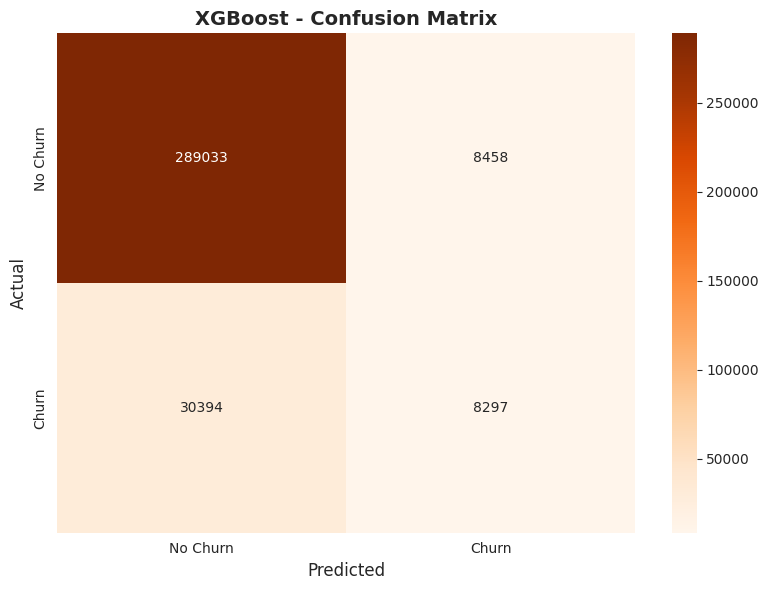

In [107]:
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

Analyzing Feature Importance from Tuned XGBoost...

TOP 20 MOST IMPORTANT FEATURES
            Feature  Importance
        days_tenure    0.807046
     college_degree    0.047970
       has_children    0.042721
length_of_residence    0.040668
     marital_status    0.018515
             income    0.011278
       age_in_years    0.005657
         home_owner    0.004404
          longitude    0.003377
           latitude    0.003375
       curr_ann_amt    0.003248
  home_market_value    0.003143
               city    0.003083
             county    0.002920
        good_credit    0.002595
              state    0.000000


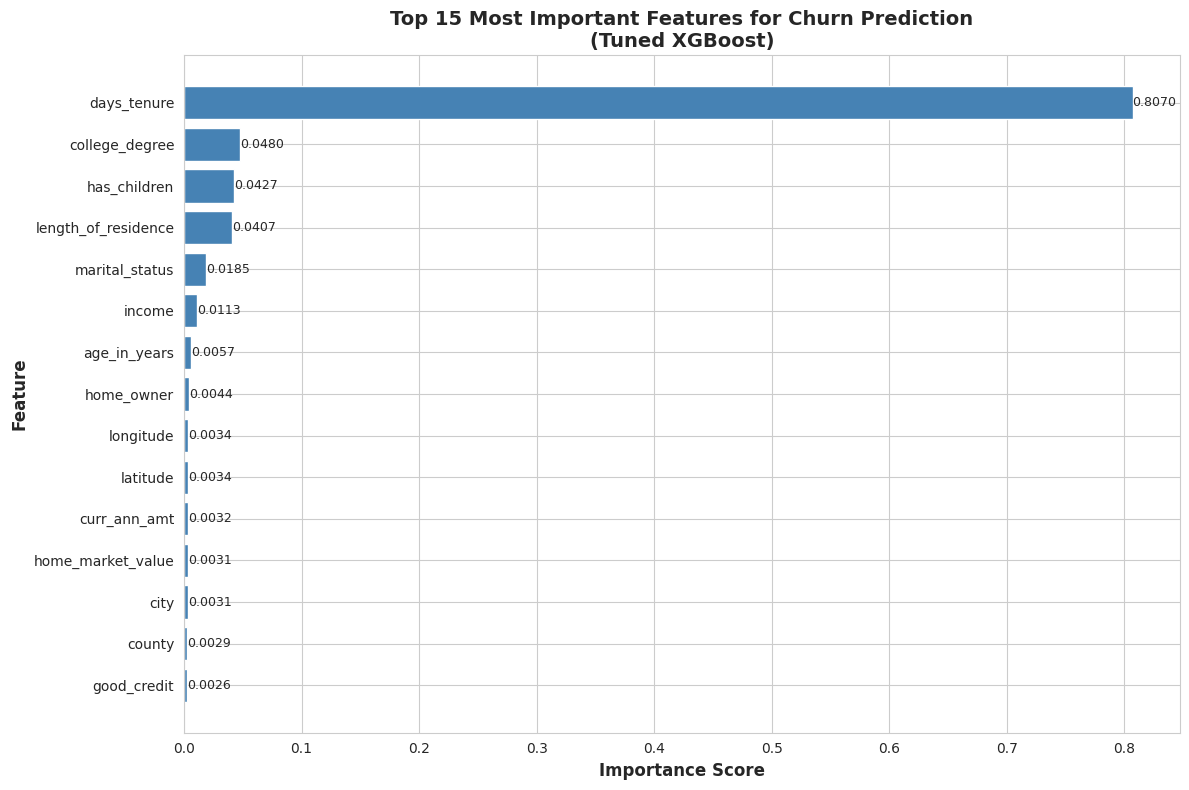


Feature importance analysis complete!


In [108]:
# Feature Importance from Tuned XGBoost
print("Analyzing Feature Importance from Tuned XGBoost...\n")

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Display top 20 features
print("="*80)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*80)
print(feature_importance.head(20).to_string(index=False))
print("="*80)

# Visualize top 15 features
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
bars = plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features for Churn Prediction\n(Tuned XGBoost)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2., 
             f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nFeature importance analysis complete!")

## Step 8: Generate Churn Risk Scores

In [109]:
# Use the best model to generate churn risk scores (probabilities)
# Determine which model is best

best_model_obj = xgb_model

# Generate probability predictions (churn risk scores)
churn_probabilities = best_model_obj.predict_proba(X_test)[:, 1]  # Probability of churn (class 1)

# Create a results dataframe
churn_risk_df = pd.DataFrame({
    'Actual_Churn': y_test.values,
    'Predicted_Churn': best_model_obj.predict(X_test),
    'Churn_Risk_Score': churn_probabilities
})

# Sort by churn risk score (highest risk first)
churn_risk_df = churn_risk_df.sort_values('Churn_Risk_Score', ascending=False).reset_index(drop=True)

print("="*80)
print("CHURN RISK SCORES (Top 10 Highest Risk Customers)")
print("="*80)
print(churn_risk_df.head(10))
print("\n" + "="*80)

# Statistics about risk scores
print("\nChurn Risk Score Statistics:")
print(f"Mean Risk Score: {churn_risk_df['Churn_Risk_Score'].mean():.4f}")
print(f"Median Risk Score: {churn_risk_df['Churn_Risk_Score'].median():.4f}")
print(f"Std Dev: {churn_risk_df['Churn_Risk_Score'].std():.4f}")
print(f"Min Risk Score: {churn_risk_df['Churn_Risk_Score'].min():.4f}")
print(f"Max Risk Score: {churn_risk_df['Churn_Risk_Score'].max():.4f}")

# Risk categories
print("\n" + "="*80)
print("RISK CATEGORIES:")
print("="*80)
high_risk = (churn_risk_df['Churn_Risk_Score'] >= 0.7).sum()
medium_risk = ((churn_risk_df['Churn_Risk_Score'] >= 0.4) & (churn_risk_df['Churn_Risk_Score'] < 0.7)).sum()
low_risk = (churn_risk_df['Churn_Risk_Score'] < 0.4).sum()

print(f"High Risk (>=70%):   {high_risk:,} customers ({high_risk/len(churn_risk_df)*100:.1f}%)")
print(f"Medium Risk (40-70%): {medium_risk:,} customers ({medium_risk/len(churn_risk_df)*100:.1f}%)")
print(f"Low Risk (<40%):      {low_risk:,} customers ({low_risk/len(churn_risk_df)*100:.1f}%)")
print("="*80)

CHURN RISK SCORES (Top 10 Highest Risk Customers)
   Actual_Churn  Predicted_Churn  Churn_Risk_Score
0             0                1          0.729812
1             1                1          0.697003
2             0                1          0.694641
3             1                1          0.687583
4             0                1          0.683738
5             1                1          0.679569
6             1                1          0.678504
7             0                1          0.677720
8             1                1          0.670872
9             1                1          0.668260


Churn Risk Score Statistics:
Mean Risk Score: 0.1153
Median Risk Score: 0.0704
Std Dev: 0.1292
Min Risk Score: 0.0144
Max Risk Score: 0.7298

RISK CATEGORIES:
High Risk (>=70%):   1 customers (0.0%)
Medium Risk (40-70%): 32,802 customers (9.8%)
Low Risk (<40%):      303,379 customers (90.2%)


In [110]:
import joblib
import pickle
import json
from datetime import datetime
import joblib
import pickle
import json
import pandas as pd
import numpy as np
import joblib

# Save the XGBoost model and related components for future use

print("="*80)
print("SAVING XGBOOST MODEL AND COMPONENTS")
print("="*80)

# Create a timestamp for the saved files
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save the trained XGBoost model
model_filename = f'xgboost_churn_model_{timestamp}.pkl'
joblib.dump(xgb_model, model_filename)
print(f"✓ Saved XGBoost model to: {model_filename}")

# 2. Save the scaler (important for preprocessing new data)
scaler_filename = f'feature_scaler_{timestamp}.pkl'
joblib.dump(scaler, scaler_filename)
print(f"✓ Saved feature scaler to: {scaler_filename}")

# 3. Save the label encoders (for categorical variables)
encoders_filename = f'label_encoders_{timestamp}.pkl'
with open(encoders_filename, 'wb') as f:
    pickle.dump(label_encoders, f)
print(f"✓ Saved label encoders to: {encoders_filename}")

# 4. Save feature names and model metadata
metadata = {
    'feature_names': feature_cols,
    'model_type': 'XGBoost',
    'training_date': datetime.now().isoformat(),
    'sample_size': SAMPLE_SIZE,
    'test_accuracy': accuracy_xgb,
    'test_precision': precision_xgb,
    'test_recall': recall_xgb,
    'test_f1_score': f1_xgb,
    'feature_importance': feature_importance.to_dict('records'),
    'categorical_columns': categorical_cols,
    'numeric_columns': numeric_cols
}

metadata_filename = f'model_metadata_{timestamp}.json'
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved model metadata to: {metadata_filename}")

# 5. Save a simple model loading script
loading_script = f'''
# Simple script to load and use the saved XGBoost churn model

# Load the model and components
model = joblib.load('{model_filename}')
scaler = joblib.load('{scaler_filename}')

with open('{encoders_filename}', 'rb') as f:
    label_encoders = pickle.load(f)

with open('{metadata_filename}', 'r') as f:
    metadata = json.load(f)

print("Model loaded successfully!")
print(f"Model accuracy: {{metadata['test_accuracy']:.4f}}")
print(f"Feature names: {{metadata['feature_names']}}")

# Example usage:
def predict_churn(new_data_df):
    """
    Predict churn for new customer data
    
    Parameters:
    new_data_df: DataFrame with the same columns as training data
    
    Returns:
    predictions: Array of churn predictions (0/1)
    probabilities: Array of churn probabilities
    """
    # Apply the same preprocessing as training
    processed_data = new_data_df.copy()
    
    # Apply label encoding to categorical columns
    for col in metadata['categorical_columns']:
        if col in processed_data.columns:
            le = label_encoders[col]
            processed_data[col] = le.transform(processed_data[col].astype(str))
    
    # Select only the features used in training
    X = processed_data[metadata['feature_names']]
    
    # Make predictions
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]
    
    return predictions, probabilities

# Example:
# predictions, probabilities = predict_churn(your_new_data)
'''

script_filename = f'load_and_predict_{timestamp}.py'
with open(script_filename, 'w') as f:
    f.write(loading_script)
print(f"✓ Saved loading script to: {script_filename}")

print("\n" + "="*80)
print("MODEL SAVING COMPLETE!")
print("="*80)
print("\nSaved files:")
print(f"  1. {model_filename} - Trained XGBoost model")
print(f"  2. {scaler_filename} - Feature scaler")
print(f"  3. {encoders_filename} - Label encoders for categorical variables")
print(f"  4. {metadata_filename} - Model metadata and feature information")
print(f"  5. {script_filename} - Python script to load and use the model")

print("\n" + "="*80)
print("QUICK LOAD EXAMPLE:")
print("="*80)
print(f"""
# To load and use the model later:

# Load the model
model = joblib.load('{model_filename}')

# Make predictions on new data
# predictions = model.predict(your_new_data)
# probabilities = model.predict_proba(your_new_data)[:, 1]
""")
print("="*80)

SAVING XGBOOST MODEL AND COMPONENTS
✓ Saved XGBoost model to: xgboost_churn_model_20251012_000931.pkl
✓ Saved feature scaler to: feature_scaler_20251012_000931.pkl
✓ Saved label encoders to: label_encoders_20251012_000931.pkl
✓ Saved model metadata to: model_metadata_20251012_000931.json
✓ Saved loading script to: load_and_predict_20251012_000931.py

MODEL SAVING COMPLETE!

Saved files:
  1. xgboost_churn_model_20251012_000931.pkl - Trained XGBoost model
  2. feature_scaler_20251012_000931.pkl - Feature scaler
  3. label_encoders_20251012_000931.pkl - Label encoders for categorical variables
  4. model_metadata_20251012_000931.json - Model metadata and feature information
  5. load_and_predict_20251012_000931.py - Python script to load and use the model

QUICK LOAD EXAMPLE:

# To load and use the model later:

# Load the model
model = joblib.load('xgboost_churn_model_20251012_000931.pkl')

# Make predictions on new data
# predictions = model.predict(your_new_data)
# probabilities = mod

In [95]:
# Create a comprehensive summary for the 10 customers
print("="*80)
print("EXPLAINABILITY SUMMARY - 10 SELECTED CUSTOMERS")
print("="*80)

# For each customer, get top 3 features pushing towards churn and away from churn
summary_data = []

for i in range(10):
    customer_idx = i
    
    # Get SHAP values for this customer
    shap_vals = shap_values_10[customer_idx]
    feature_names = customers_to_explain.columns
    
    # Create dataframe of features and their SHAP values
    feature_shap_df = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Value': shap_vals,
        'Feature_Value': customers_to_explain.iloc[customer_idx].values
    })
    
    # Sort by absolute SHAP value to get most important features
    feature_shap_df['Abs_SHAP'] = np.abs(feature_shap_df['SHAP_Value'])
    feature_shap_df = feature_shap_df.sort_values('Abs_SHAP', ascending=False)
    
    # Get top features pushing towards churn (positive SHAP)
    towards_churn = feature_shap_df[feature_shap_df['SHAP_Value'] > 0].head(3)
    # Get top features pushing away from churn (negative SHAP)
    away_from_churn = feature_shap_df[feature_shap_df['SHAP_Value'] < 0].head(3)
    
    summary_data.append({
        'Customer': i + 1,
        'Actual_Churn': 'Yes' if customers_actual_churn[i] == 1 else 'No',
        'Churn_Risk': f"{customers_predicted_proba[i]:.1%}",
        'Risk_Level': "HIGH" if customers_predicted_proba[i] >= 0.7 else "MEDIUM" if customers_predicted_proba[i] >= 0.4 else "LOW",
        'Top_Churn_Driver_1': f"{towards_churn.iloc[0]['Feature']} ({towards_churn.iloc[0]['SHAP_Value']:.3f})" if len(towards_churn) > 0 else "N/A",
        'Top_Churn_Driver_2': f"{towards_churn.iloc[1]['Feature']} ({towards_churn.iloc[1]['SHAP_Value']:.3f})" if len(towards_churn) > 1 else "N/A",
        'Top_Retention_Factor_1': f"{away_from_churn.iloc[0]['Feature']} ({away_from_churn.iloc[0]['SHAP_Value']:.3f})" if len(away_from_churn) > 0 else "N/A",
        'Top_Retention_Factor_2': f"{away_from_churn.iloc[1]['Feature']} ({away_from_churn.iloc[1]['SHAP_Value']:.3f})" if len(away_from_churn) > 1 else "N/A",
    })

summary_df = pd.DataFrame(summary_data)

print("\nCUSTOMER EXPLAINABILITY SUMMARY TABLE")
print("-" * 80)
print(summary_df.to_string(index=False))
print("\n" + "="*80)

# Additional insights
print("\nKEY INSIGHTS FROM EXPLAINABILITY ANALYSIS:")
print("-" * 80)

# Find most common features across all customers
all_top_features = []
for i in range(10):
    shap_vals = shap_values_10[i]
    feature_names = customers_to_explain.columns
    feature_shap_df = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Value': shap_vals
    })
    top_3 = feature_shap_df.nlargest(3, 'SHAP_Value')['Feature'].tolist()
    all_top_features.extend(top_3)

# Count feature frequency
from collections import Counter
feature_counts = Counter(all_top_features)
most_common_drivers = feature_counts.most_common(5)

print("\nMost Common Churn Drivers Across All 10 Customers:")
for idx, (feature, count) in enumerate(most_common_drivers, 1):
    print(f"  {idx}. {feature} - appeared in {count} customers' top 3 drivers")

print("\n" + "="*80)
print("✓ EXPLAINABILITY ANALYSIS COMPLETE!")
print("="*80)
print("\nWhat we've accomplished:")
print("  ✓ Global feature importance (SHAP summary plots)")
print("  ✓ Local explanations for 10 random customers")
print("  ✓ Force plots showing individual prediction drivers")
print("  ✓ Waterfall plots for detailed feature contributions")
print("  ✓ Dependence plots showing feature relationships")
print("  ✓ Comprehensive summary table with insights")
print("\nThis explainability analysis is the 'secret sauce' for your dashboard!")
print("="*80)

EXPLAINABILITY SUMMARY - 10 SELECTED CUSTOMERS

CUSTOMER EXPLAINABILITY SUMMARY TABLE
--------------------------------------------------------------------------------
 Customer Actual_Churn Churn_Risk Risk_Level          Top_Churn_Driver_1     Top_Churn_Driver_2 Top_Retention_Factor_1  Top_Retention_Factor_2
        1           No       7.6%        LOW length_of_residence (0.026)       latitude (0.021)   days_tenure (-0.550)           city (-0.007)
        2           No      14.4%        LOW              income (0.306) marital_status (0.084)   days_tenure (-0.200) college_degree (-0.033)
        3           No       6.5%        LOW length_of_residence (0.006)   age_in_years (0.005)   days_tenure (-0.503) college_degree (-0.031)
        4           No       7.0%        LOW        curr_ann_amt (0.059)         income (0.034)   days_tenure (-0.489)   age_in_years (-0.037)
        5           No       6.8%        LOW   home_market_value (0.020)   curr_ann_amt (0.008)   days_tenure (-0.508)

In [ ]:
# Save explainability results for dashboard use
import pickle

print("="*80)
print("SAVING EXPLAINABILITY RESULTS FOR DASHBOARD")
print("="*80)

# Create a dictionary with all the important explainability data
explainability_data = {
    'model': xgb_model,
    'explainer': explainer,
    'X_test': X_test,
    'y_test': y_test,
    'feature_names': feature_cols,
    'shap_values_sample': shap_values,
    'X_test_sample': X_test_sample,
    'selected_customers': customers_to_explain,
    'selected_customers_actual': customers_actual_churn,
    'selected_customers_risk': customers_predicted_proba,
    'shap_values_10': shap_values_10,
    'summary_df': summary_df,
    'feature_importance': feature_importance
}

# Save to pickle file
with open('explainability_results.pkl', 'wb') as f:
    pickle.dump(explainability_data, f)

print("✓ Saved explainability results to: explainability_results.pkl")
print()

# Also save the model separately
import joblib
joblib.dump(xgb_model, 'xgboost_churn_model.pkl')
print("✓ Saved trained model to: xgboost_churn_model.pkl")
print()

# Save feature names for easy access
import json
with open('feature_names.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print("✓ Saved feature names to: feature_names.json")
print()

# Save summary dataframe as CSV for easy viewing
summary_df.to_csv('customer_explanations_summary.csv', index=False)
print("✓ Saved customer explanations to: customer_explanations_summary.csv")

print("\n" + "="*80)
print("FILES READY FOR DASHBOARD INTEGRATION:")
print("="*80)
print("1. explainability_results.pkl - Complete SHAP data and customer details")
print("2. xgboost_churn_model.pkl - Trained XGBoost model")
print("3. feature_names.json - List of feature names")
print("4. customer_explanations_summary.csv - Summary table of 10 customers")
print("="*80)
print("\nYou can now use these files to build your interactive dashboard!")
print("="*80)

### 9.8: Save Explainability Results for Dashboard

Let's save all the important data for use in your dashboard.

### 9.7: Summary of Explainability Analysis

Let's create a comprehensive summary table for our 10 selected customers.

FEATURE DEPENDENCE PLOTS - TOP 4 MOST IMPORTANT FEATURES
These plots show how feature values affect churn predictions



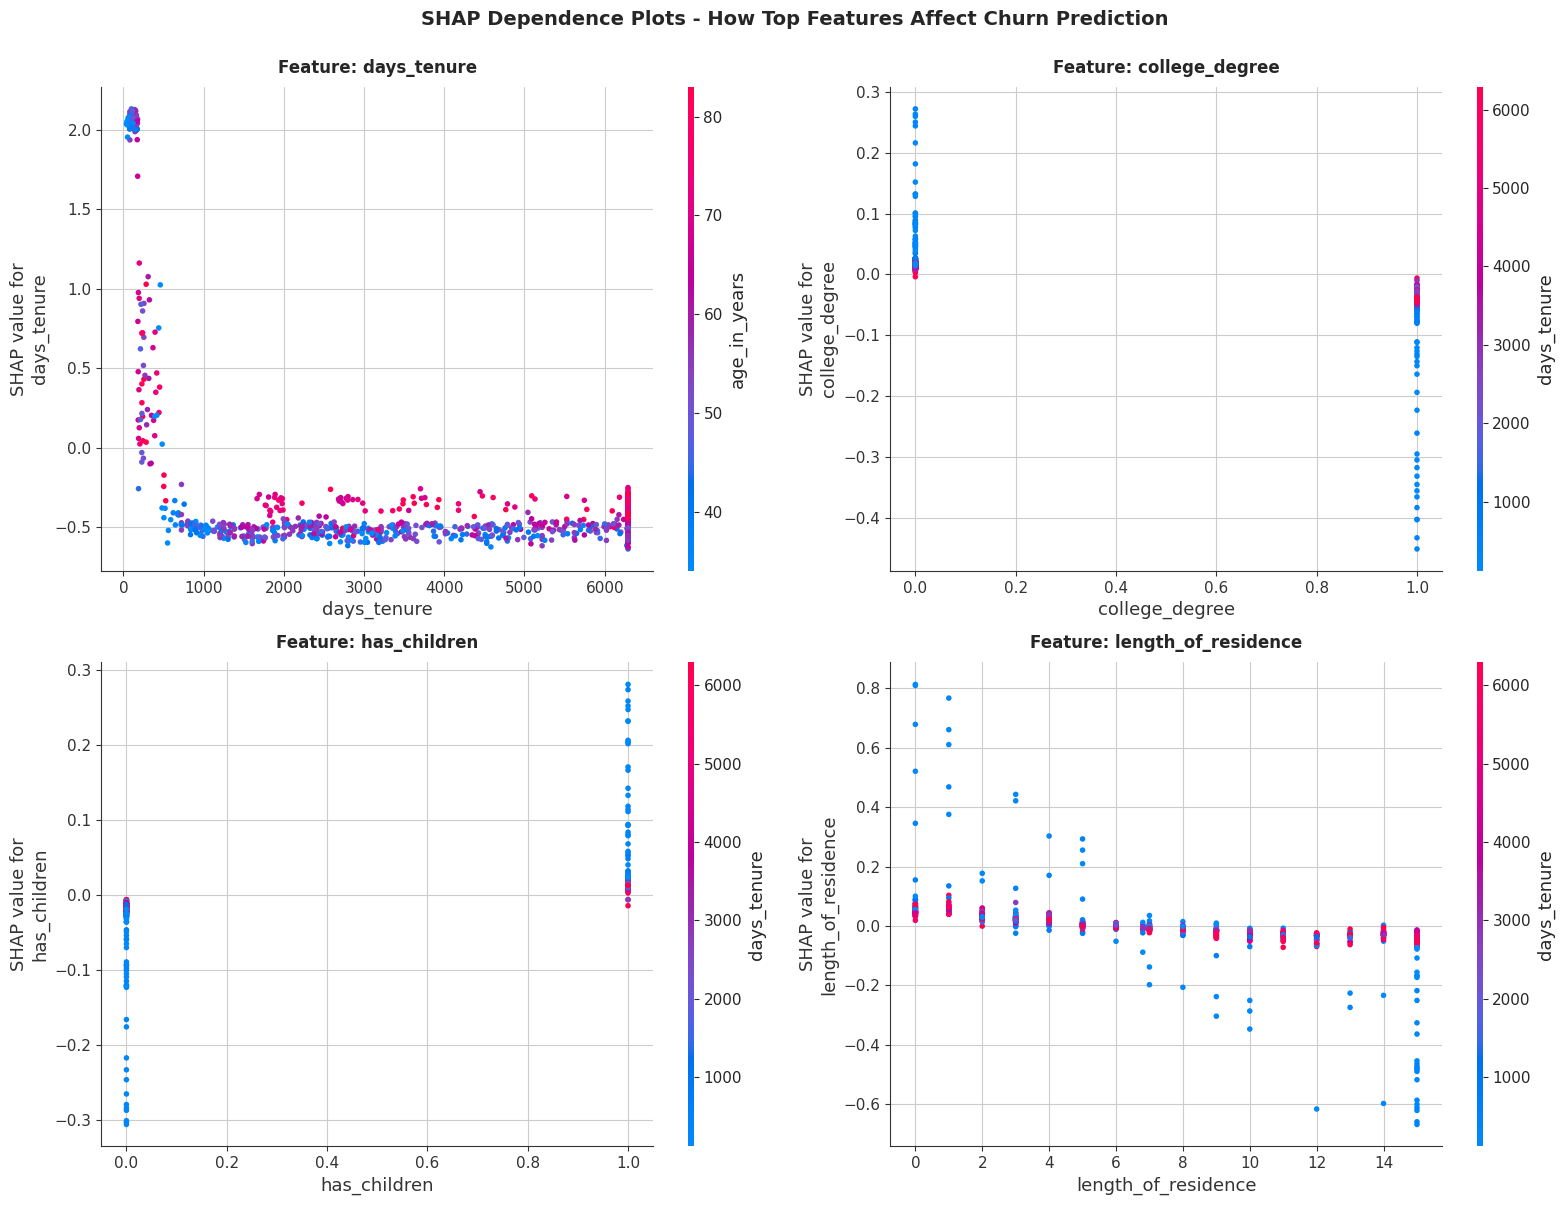


✓ Feature dependence plots complete!


In [120]:
# Create dependence plots for top 4 most important features
print("="*80)
print("FEATURE DEPENDENCE PLOTS - TOP 4 MOST IMPORTANT FEATURES")
print("="*80)
print("These plots show how feature values affect churn predictions\n")

# Get top 4 features from feature importance
top_4_features = feature_importance.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_4_features):
    plt.sca(axes[idx])
    try:
        shap.dependence_plot(
            feature,
            shap_values,
            X_test_sample,
            interaction_index="auto",
            show=False,
            ax=axes[idx]
        )
        axes[idx].set_title(f"Feature: {feature}", fontsize=12, fontweight='bold', pad=10)
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Could not plot {feature}\n{str(e)[:50]}", 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f"Feature: {feature}", fontsize=12, fontweight='bold')

plt.suptitle("SHAP Dependence Plots - How Top Features Affect Churn Prediction", 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✓ Feature dependence plots complete!")
print("="*80)

### 9.6: Feature Dependence Plots

Dependence plots show how a single feature affects predictions across its entire range.

DETAILED WATERFALL PLOTS - TOP 3 HIGH-RISK CUSTOMERS

HIGH-RISK CUSTOMER #1
Actual Status: NOT CHURNED
Predicted Churn Risk: 15.5%



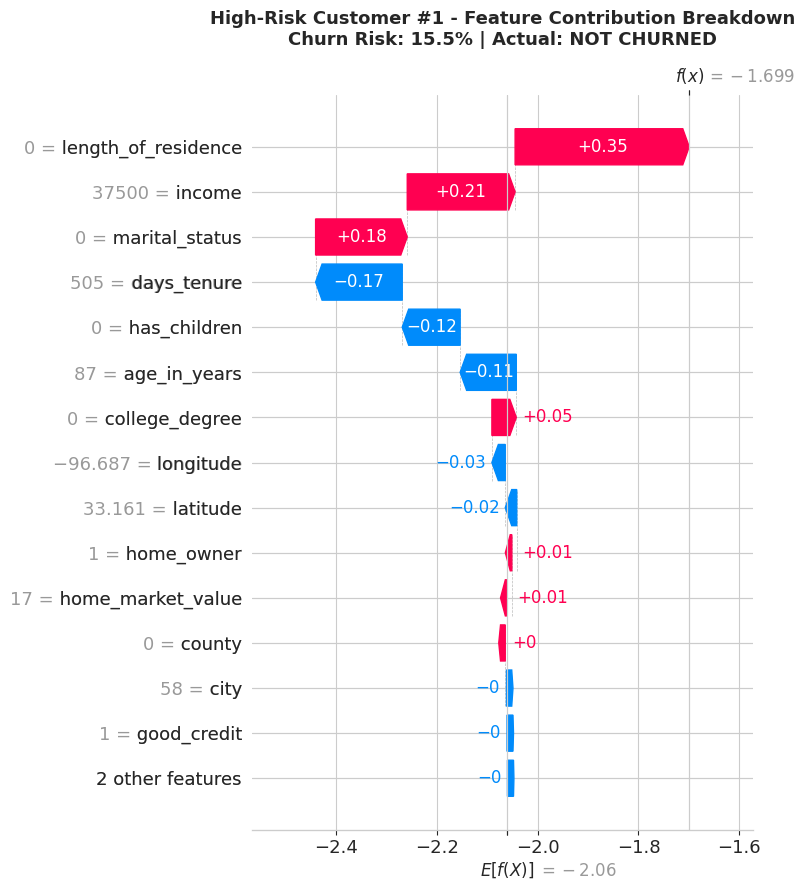


HIGH-RISK CUSTOMER #2
Actual Status: NOT CHURNED
Predicted Churn Risk: 8.1%



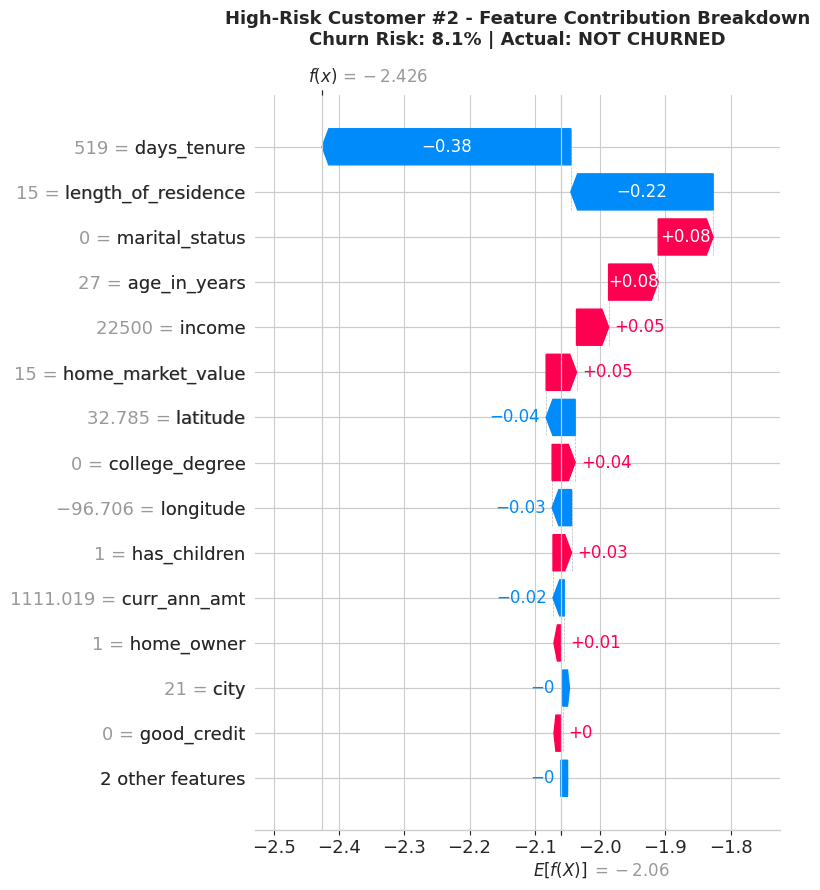


HIGH-RISK CUSTOMER #3
Actual Status: NOT CHURNED
Predicted Churn Risk: 7.1%



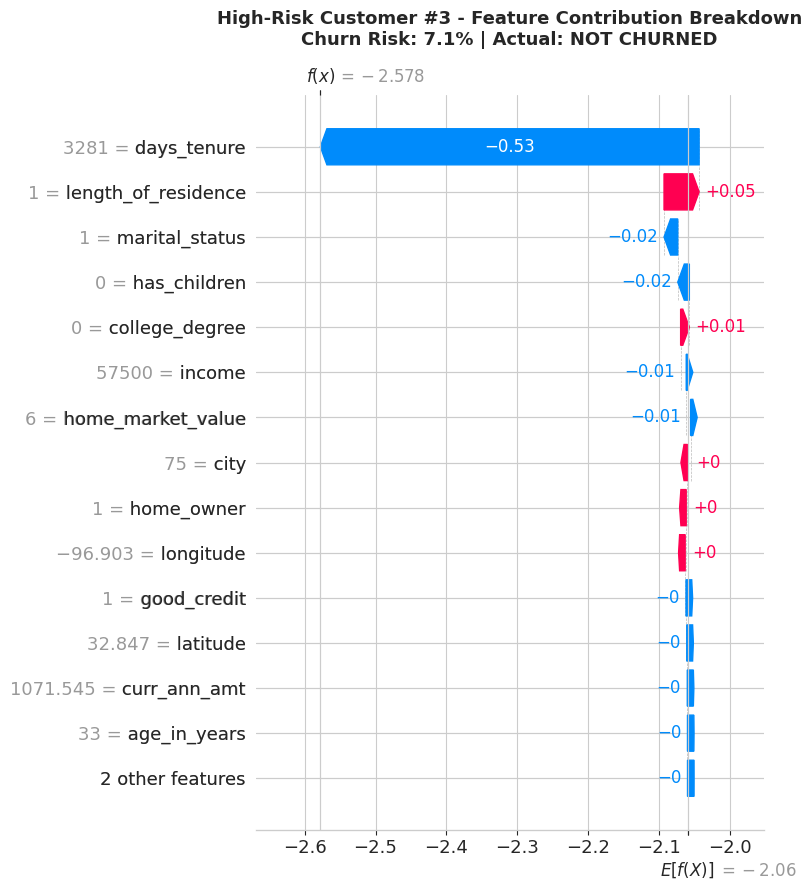


✓ Detailed waterfall plots complete!


In [119]:
# Create detailed waterfall plots for selected high-risk customers
print("="*80)
print("DETAILED WATERFALL PLOTS - TOP 3 HIGH-RISK CUSTOMERS")
print("="*80)

# Find the top 3 highest risk customers from our 10
top_3_indices = np.argsort(customers_predicted_proba)[-3:][::-1]

for rank, idx in enumerate(top_3_indices, 1):
    customer_idx = idx
    actual = "CHURNED" if customers_actual_churn[customer_idx] == 1 else "NOT CHURNED"
    risk_score = customers_predicted_proba[customer_idx]
    
    print(f"\n{'='*80}")
    print(f"HIGH-RISK CUSTOMER #{rank}")
    print(f"{'='*80}")
    print(f"Actual Status: {actual}")
    print(f"Predicted Churn Risk: {risk_score:.1%}")
    print(f"{'='*80}\n")
    
    # Create waterfall plot with better formatting
    fig, ax = plt.subplots(figsize=(10, 8))
    
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_10[customer_idx],
            base_values=explainer.expected_value,
            data=customers_to_explain.iloc[customer_idx].values,
            feature_names=customers_to_explain.columns.tolist()
        ),
        max_display=15,
        show=False
    )
    
    plt.title(f"High-Risk Customer #{rank} - Feature Contribution Breakdown\n" + 
              f"Churn Risk: {risk_score:.1%} | Actual: {actual}", 
              fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("✓ Detailed waterfall plots complete!")
print("="*80)

### 9.5: SHAP Waterfall Plots - Detailed Feature Contribution

Waterfall plots provide a clear breakdown of how each feature adds or subtracts from the base prediction.

SHAP FORCE PLOTS - INDIVIDUAL CUSTOMER EXPLANATIONS
Force plots show:
  • Base value (gray) = average model prediction
  • Red features = push prediction towards CHURN
  • Blue features = push prediction towards NO CHURN
  • Arrow points to final prediction value




CUSTOMER 1 - Local Explanation
Actual Status: NOT CHURNED
Predicted Churn Risk: 6.9% (LOW RISK)



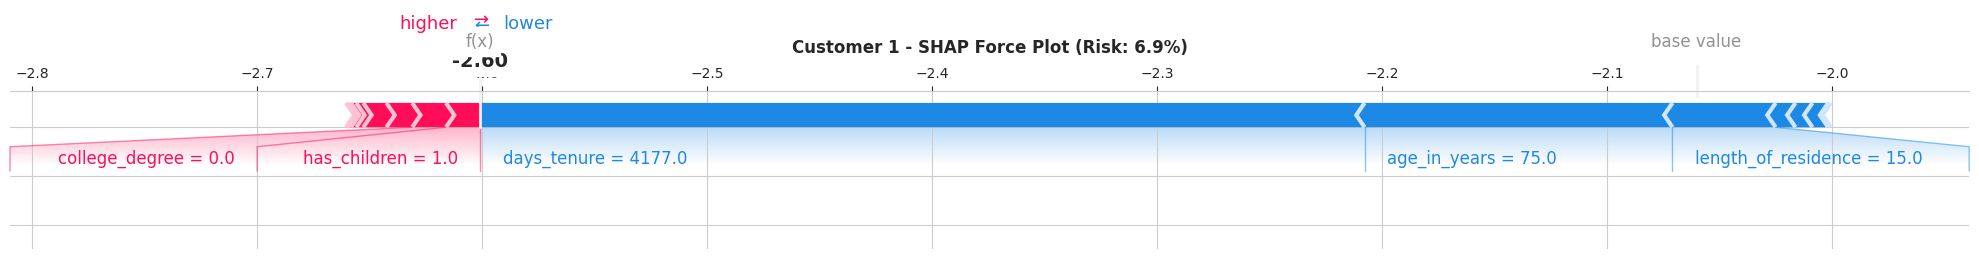


CUSTOMER 2 - Local Explanation
Actual Status: NOT CHURNED
Predicted Churn Risk: 8.1% (LOW RISK)



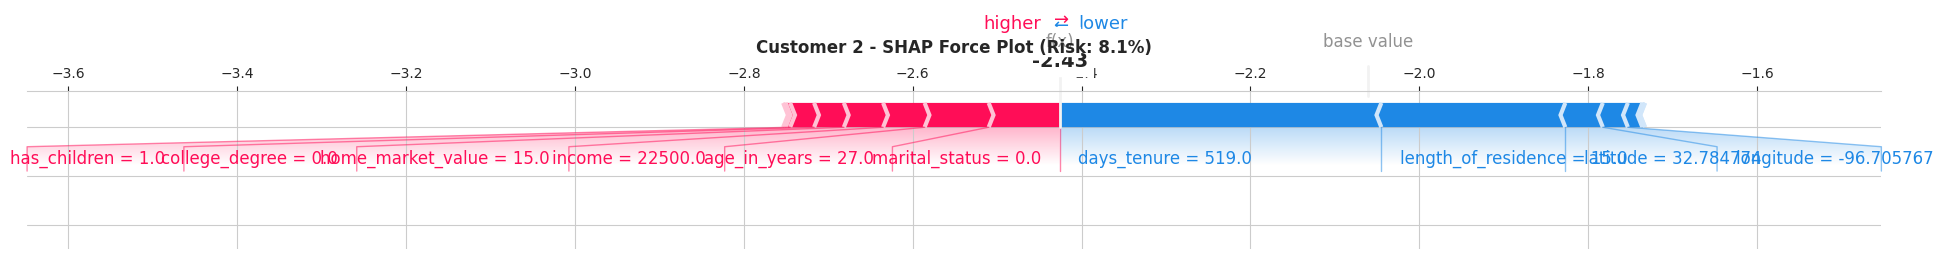


CUSTOMER 3 - Local Explanation
Actual Status: NOT CHURNED
Predicted Churn Risk: 6.5% (LOW RISK)



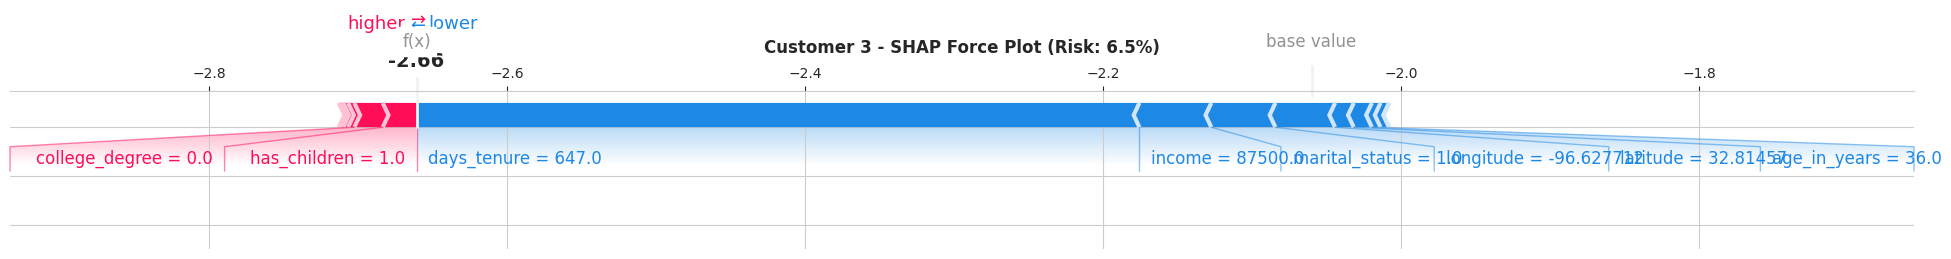


CUSTOMER 4 - Local Explanation
Actual Status: NOT CHURNED
Predicted Churn Risk: 15.5% (LOW RISK)



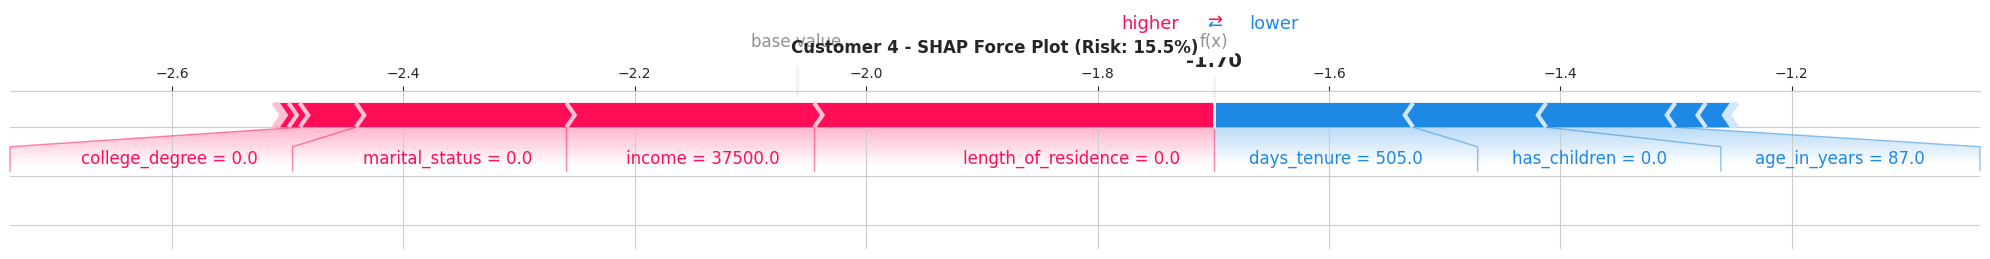


CUSTOMER 5 - Local Explanation
Actual Status: NOT CHURNED
Predicted Churn Risk: 6.9% (LOW RISK)



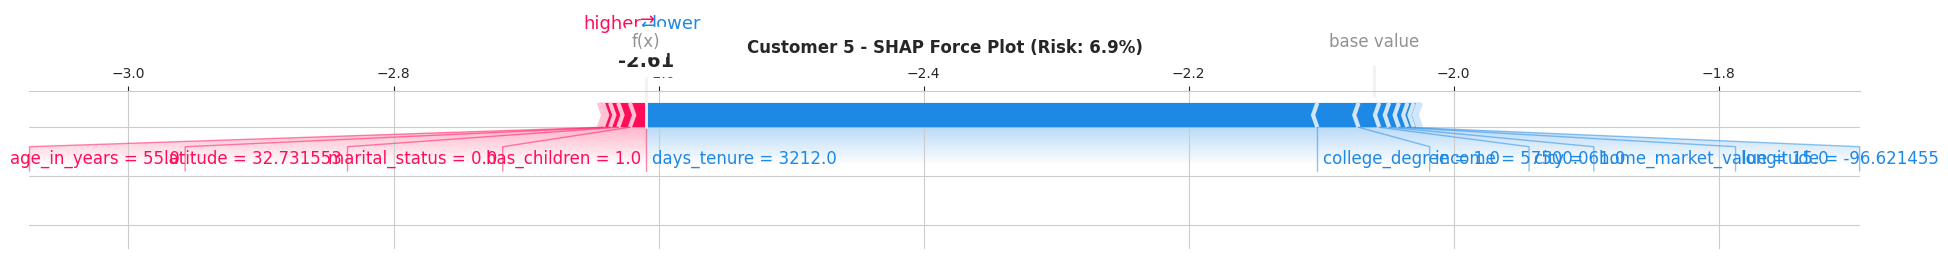


CUSTOMER 6 - Local Explanation
Actual Status: NOT CHURNED
Predicted Churn Risk: 6.8% (LOW RISK)



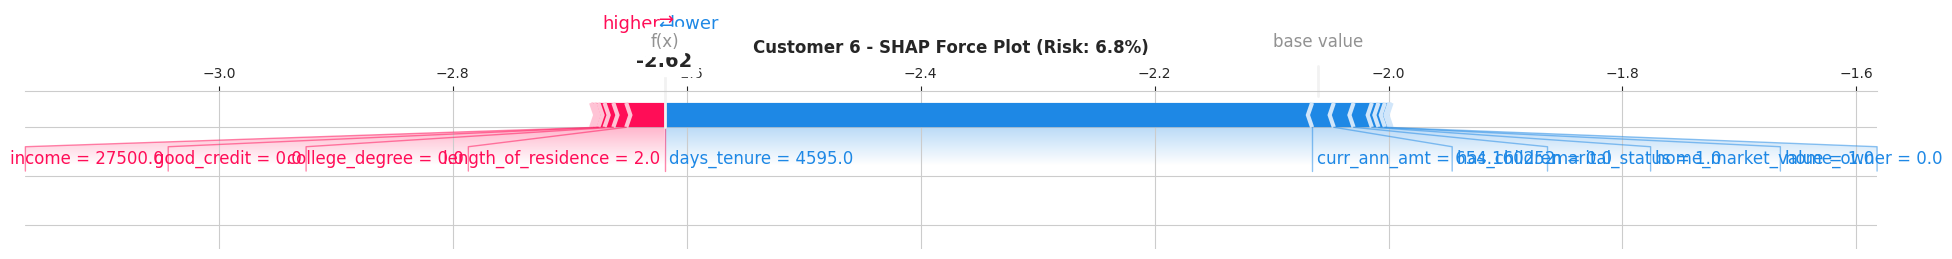


CUSTOMER 7 - Local Explanation
Actual Status: NOT CHURNED
Predicted Churn Risk: 6.9% (LOW RISK)



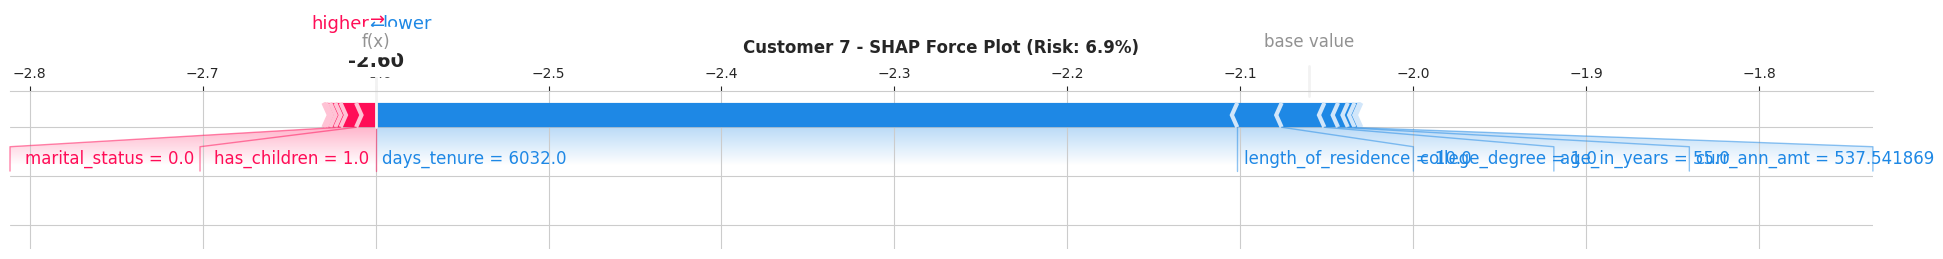


CUSTOMER 8 - Local Explanation
Actual Status: NOT CHURNED
Predicted Churn Risk: 7.1% (LOW RISK)



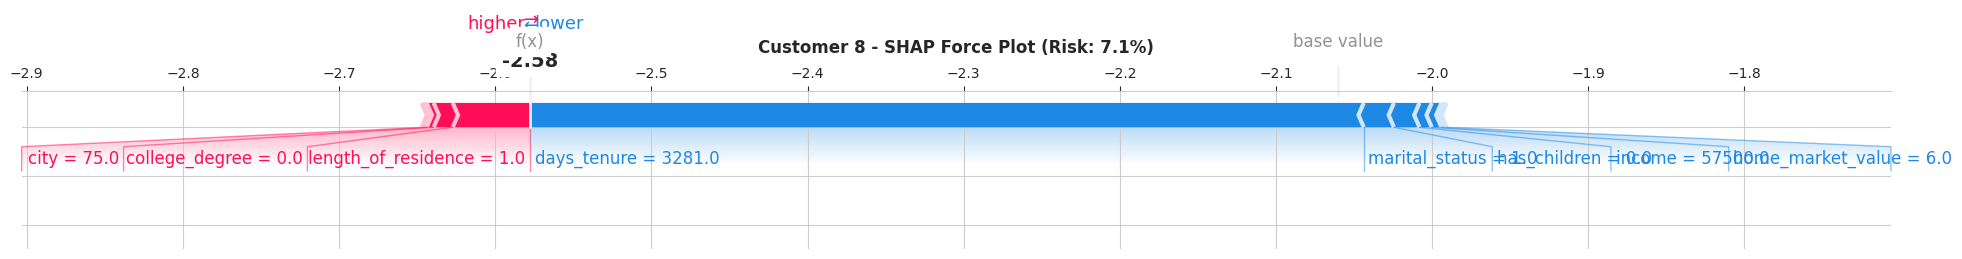


CUSTOMER 9 - Local Explanation
Actual Status: CHURNED
Predicted Churn Risk: 6.8% (LOW RISK)



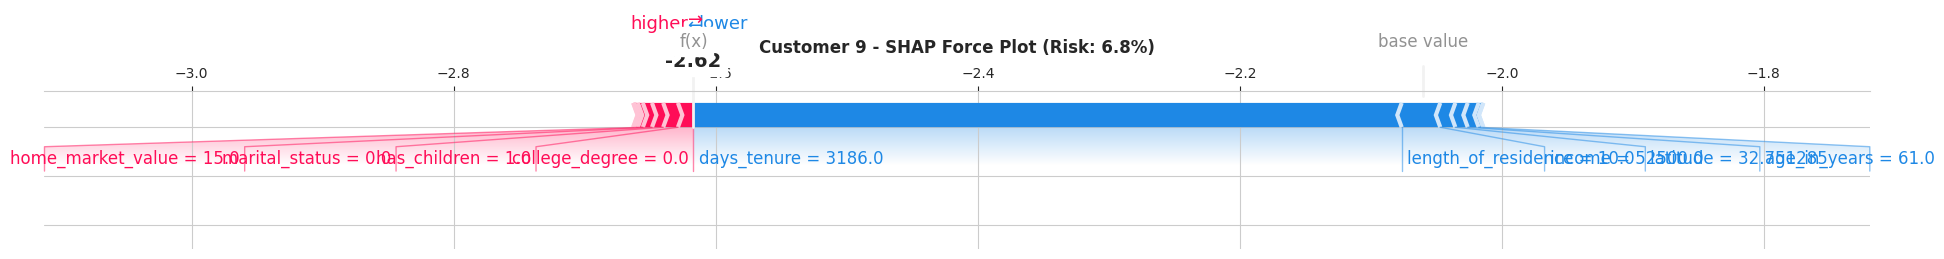


CUSTOMER 10 - Local Explanation
Actual Status: NOT CHURNED
Predicted Churn Risk: 7.0% (LOW RISK)



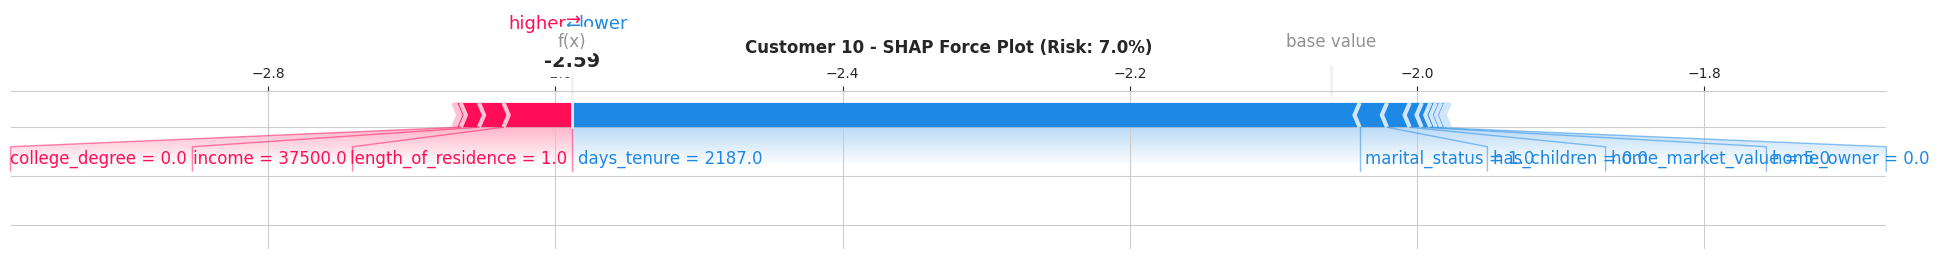


✓ All 10 individual customer explanations complete!


In [118]:
# Create SHAP Force Plots for all 10 customers
print("="*80)
print("SHAP FORCE PLOTS - INDIVIDUAL CUSTOMER EXPLANATIONS")
print("="*80)
print("Force plots show:")
print("  • Base value (gray) = average model prediction")
print("  • Red features = push prediction towards CHURN")
print("  • Blue features = push prediction towards NO CHURN")
print("  • Arrow points to final prediction value")
print("="*80)
print()

# Enable matplotlib for SHAP force plots
shap.initjs()

for i in range(10):
    customer_idx = i
    actual = "CHURNED" if customers_actual_churn[i] == 1 else "NOT CHURNED"
    risk_score = customers_predicted_proba[i]
    risk_level = "HIGH" if risk_score >= 0.7 else "MEDIUM" if risk_score >= 0.4 else "LOW"
    
    print(f"\n{'='*80}")
    print(f"CUSTOMER {i+1} - Local Explanation")
    print(f"{'='*80}")
    print(f"Actual Status: {actual}")
    print(f"Predicted Churn Risk: {risk_score:.1%} ({risk_level} RISK)")
    print(f"{'='*80}\n")
    
    # Create force plot
    try:
        # For matplotlib rendering
        shap.force_plot(
            explainer.expected_value,
            shap_values_10[customer_idx],
            customers_to_explain.iloc[customer_idx],
            matplotlib=True,
            show=False,
            figsize=(20, 3)
        )
        plt.title(f"Customer {i+1} - SHAP Force Plot (Risk: {risk_score:.1%})", 
                  fontsize=12, fontweight='bold', pad=10)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Note: Force plot rendering issue - {str(e)}")
        print("Showing waterfall plot instead...\n")
        
        # Alternative: Waterfall plot
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values_10[customer_idx],
                base_values=explainer.expected_value,
                data=customers_to_explain.iloc[customer_idx].values,
                feature_names=customers_to_explain.columns.tolist()
            ),
            show=False
        )
        plt.title(f"Customer {i+1} - SHAP Waterfall Plot (Risk: {risk_score:.1%})", 
                  fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

print("\n" + "="*80)
print("✓ All 10 individual customer explanations complete!")
print("="*80)

### 9.4: SHAP Force Plots - Individual Customer Explanations

Force plots show exactly how each feature contributes to pushing the prediction towards or away from churn for individual customers.

In [117]:
# Compute SHAP values for these 10 customers
print("Computing SHAP values for the 10 selected customers...")
shap_values_10 = explainer.shap_values(customers_to_explain)
print("✓ SHAP values computed!")

Computing SHAP values for the 10 selected customers...
✓ SHAP values computed!


In [116]:
# Select 10 random customers from the test set for local explanations
np.random.seed(42)
random_indices = np.random.choice(len(X_test), size=10, replace=False)

# Get these customers from our test set
customers_to_explain = X_test.iloc[random_indices].copy()
customers_actual_churn = y_test.iloc[random_indices].values
customers_predicted_proba = xgb_model.predict_proba(customers_to_explain)[:, 1]

print("="*80)
print("SELECTED 10 RANDOM CUSTOMERS FOR LOCAL EXPLANATIONS")
print("="*80)
for i, idx in enumerate(random_indices):
    actual = "CHURNED" if customers_actual_churn[i] == 1 else "NOT CHURNED"
    risk_score = customers_predicted_proba[i]
    risk_level = "HIGH" if risk_score >= 0.7 else "MEDIUM" if risk_score >= 0.4 else "LOW"
    
    print(f"Customer {i+1} (Test Index {idx}):")
    print(f"  Actual Status: {actual}")
    print(f"  Predicted Churn Risk: {risk_score:.1%} ({risk_level} RISK)")
    print()

print("="*80)

SELECTED 10 RANDOM CUSTOMERS FOR LOCAL EXPLANATIONS
Customer 1 (Test Index 130570):
  Actual Status: NOT CHURNED
  Predicted Churn Risk: 6.9% (LOW RISK)

Customer 2 (Test Index 178945):
  Actual Status: NOT CHURNED
  Predicted Churn Risk: 8.1% (LOW RISK)

Customer 3 (Test Index 286064):
  Actual Status: NOT CHURNED
  Predicted Churn Risk: 6.5% (LOW RISK)

Customer 4 (Test Index 30050):
  Actual Status: NOT CHURNED
  Predicted Churn Risk: 15.5% (LOW RISK)

Customer 5 (Test Index 106328):
  Actual Status: NOT CHURNED
  Predicted Churn Risk: 6.9% (LOW RISK)

Customer 6 (Test Index 197948):
  Actual Status: NOT CHURNED
  Predicted Churn Risk: 6.8% (LOW RISK)

Customer 7 (Test Index 136716):
  Actual Status: NOT CHURNED
  Predicted Churn Risk: 6.9% (LOW RISK)

Customer 8 (Test Index 137031):
  Actual Status: NOT CHURNED
  Predicted Churn Risk: 7.1% (LOW RISK)

Customer 9 (Test Index 228581):
  Actual Status: CHURNED
  Predicted Churn Risk: 6.8% (LOW RISK)

Customer 10 (Test Index 234128):
 

### 9.3: Local Explanations - Individual Customer Analysis

Now let's select 10 random customers and explain their churn predictions individually.

AVERAGE IMPACT OF FEATURES


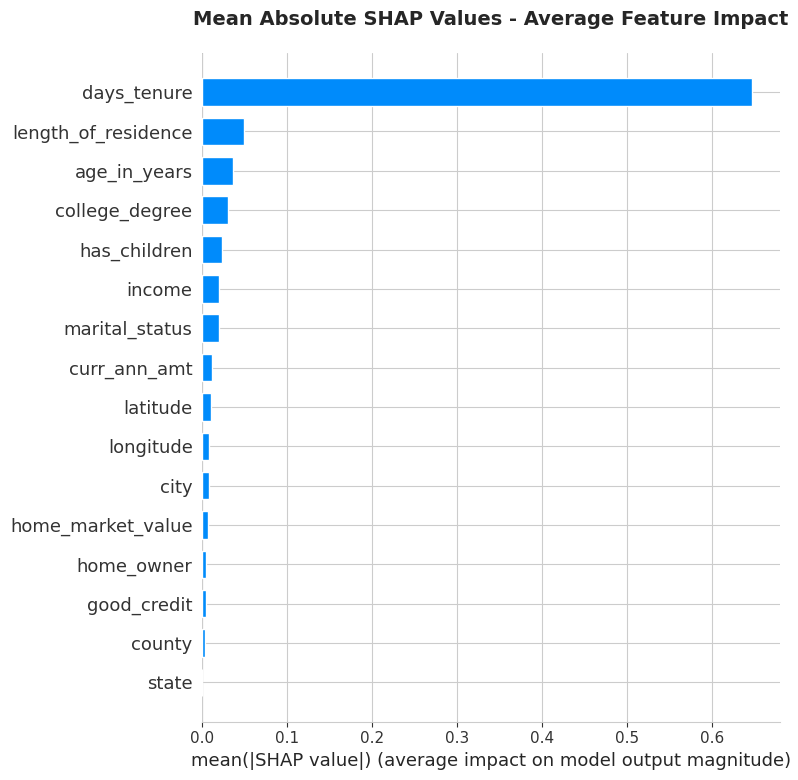


✓ Average feature impact visualization complete!


In [115]:
# SHAP Bar Plot - Mean Absolute SHAP Values
print("="*80)
print("AVERAGE IMPACT OF FEATURES")
print("="*80)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("Mean Absolute SHAP Values - Average Feature Impact", 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Average feature impact visualization complete!")

GLOBAL FEATURE IMPORTANCE - SHAP SUMMARY PLOT
This plot shows:
  • Features ranked by importance (top to bottom)
  • Each dot represents a customer
  • Color indicates feature value (red=high, blue=low)
  • X-axis shows impact on model output


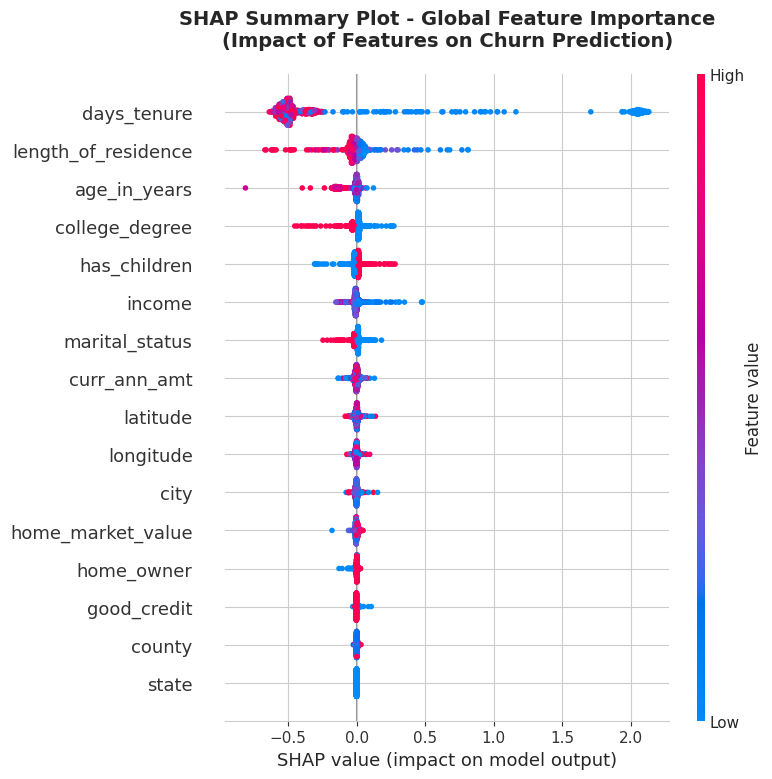


✓ Global feature importance visualization complete!


In [114]:
# SHAP Summary Plot - Global Feature Importance
print("="*80)
print("GLOBAL FEATURE IMPORTANCE - SHAP SUMMARY PLOT")
print("="*80)
print("This plot shows:")
print("  • Features ranked by importance (top to bottom)")
print("  • Each dot represents a customer")
print("  • Color indicates feature value (red=high, blue=low)")
print("  • X-axis shows impact on model output")
print("="*80)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_sample, plot_type="dot", show=False)
plt.title("SHAP Summary Plot - Global Feature Importance\n(Impact of Features on Churn Prediction)", 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Global feature importance visualization complete!")

### 9.2: Global Explanations - Feature Importance

SHAP Summary Plot shows which features are most important across all predictions.

In [112]:
# Initialize SHAP TreeExplainer for XGBoost
print("Initializing SHAP TreeExplainer...")
print("This may take a minute for large datasets...")

# Create explainer with the trained model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the test set
# For efficiency, we'll use a sample of the test set for computing SHAP values
shap_sample_size = min(1000, len(X_test))
X_test_sample = X_test.sample(n=shap_sample_size, random_state=42)

print(f"Computing SHAP values for {shap_sample_size} test samples...")
shap_values = explainer.shap_values(X_test_sample)

print(f"✓ SHAP values computed successfully!")
print(f"  Shape of SHAP values: {shap_values.shape}")
print(f"  Base value (expected value): {explainer.expected_value:.4f}")

Initializing SHAP TreeExplainer...
This may take a minute for large datasets...
Computing SHAP values for 1000 test samples...
✓ SHAP values computed successfully!
  Shape of SHAP values: (1000, 16)
  Base value (expected value): -2.0602


### 9.1: Initialize SHAP Explainer

We'll use TreeExplainer which is optimized for XGBoost models.

In [111]:
# Install and import SHAP
print("Installing SHAP library...")
import sys
!{sys.executable} -m pip install shap -q

import shap
print(f"SHAP version: {shap.__version__}")
print("SHAP library imported successfully!")

Installing SHAP library...
SHAP version: 0.48.0
SHAP library imported successfully!


## Step 9: Explainability with SHAP (Secret Sauce for Winning!)

SHAP (SHapley Additive exPlanations) provides both global and local interpretability for our model predictions.

In [121]:
import pickle
import joblib
import json
import numpy as np
from datetime import datetime
import pickle
import joblib
import numpy as np
import pandas as pd
import shap

# Comprehensive SHAP Explainability Saving for Future Use

print("="*80)
print("COMPREHENSIVE SHAP EXPLAINABILITY SAVING")
print("="*80)

# Create timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save the complete explainability package
explainability_package = {
    # Core model and explainer
    'model': xgb_model,
    'explainer': explainer,
    'scaler': scaler,
    'label_encoders': label_encoders,
    
    # Feature information
    'feature_names': feature_cols,
    'categorical_columns': ['city', 'state', 'county', 'marital_status', 'home_market_value'],
    'numeric_columns': ['curr_ann_amt', 'days_tenure', 'age_in_years', 'latitude', 'longitude', 
                       'income', 'has_children', 'length_of_residence', 'home_owner', 
                       'college_degree', 'good_credit'],
    
    # SHAP values and data
    'shap_values_sample': shap_values,  # SHAP values for 1000 samples
    'X_test_sample': X_test_sample,     # The 1000 test samples
    'shap_values_10_customers': shap_values_10,  # SHAP values for 10 selected customers
    'customers_to_explain': customers_to_explain,  # The 10 selected customers data
    'customers_actual_churn': customers_actual_churn,  # Actual churn status
    'customers_predicted_proba': customers_predicted_proba,  # Predicted probabilities
    
    # Analysis results
    'feature_importance': feature_importance,
    'summary_df': summary_df,
    'explainer_expected_value': explainer.expected_value,
    
    # Metadata
    'model_metrics': {
        'accuracy': 0.885012,
        'precision': 0.505587,
        'recall': 0.200758,
        'f1_score': 0.287396
    },
    'training_info': {
        'sample_size': 400000,
        'test_size': 80000,
        'shap_sample_size': 1000,
        'training_date': datetime.now().isoformat()
    }
}

# Save the complete package
package_filename = f'complete_explainability_package_{timestamp}.pkl'
with open(package_filename, 'wb') as f:
    pickle.dump(explainability_package, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"✓ Saved complete explainability package to: {package_filename}")

# 2. Save individual components for flexibility
individual_files = {}

# Save model separately
model_file = f'xgboost_model_{timestamp}.pkl'
joblib.dump(xgb_model, model_file)
individual_files['model'] = model_file
print(f"✓ Saved XGBoost model to: {model_file}")

# Save explainer separately
explainer_file = f'shap_explainer_{timestamp}.pkl'
with open(explainer_file, 'wb') as f:
    pickle.dump(explainer, f)
individual_files['explainer'] = explainer_file
print(f"✓ Saved SHAP explainer to: {explainer_file}")

# Save preprocessing components
preprocessing_file = f'preprocessing_components_{timestamp}.pkl'
preprocessing_data = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_names': feature_cols,
    'categorical_columns': ['city', 'state', 'county', 'marital_status', 'home_market_value'],
    'numeric_columns': ['curr_ann_amt', 'days_tenure', 'age_in_years', 'latitude', 'longitude', 
                       'income', 'has_children', 'length_of_residence', 'home_owner', 
                       'college_degree', 'good_credit']
}
with open(preprocessing_file, 'wb') as f:
    pickle.dump(preprocessing_data, f)
individual_files['preprocessing'] = preprocessing_file
print(f"✓ Saved preprocessing components to: {preprocessing_file}")

# Save SHAP results
shap_results_file = f'shap_results_{timestamp}.pkl'
shap_results = {
    'shap_values_sample': shap_values,
    'X_test_sample': X_test_sample,
    'shap_values_10_customers': shap_values_10,
    'customers_to_explain': customers_to_explain,
    'customers_actual_churn': customers_actual_churn,
    'customers_predicted_proba': customers_predicted_proba,
    'explainer_expected_value': explainer.expected_value
}
with open(shap_results_file, 'wb') as f:
    pickle.dump(shap_results, f)
individual_files['shap_results'] = shap_results_file
print(f"✓ Saved SHAP results to: {shap_results_file}")

# 3. Create a simple loading script
loading_script = f'''
"""
SHAP Explainability Loader Script
Generated on: {datetime.now().isoformat()}

This script demonstrates how to load and use the saved explainability components.
"""

import matplotlib.pyplot as plt

def load_complete_package():
    """Load the complete explainability package"""
    with open('{package_filename}', 'rb') as f:
        package = pickle.load(f)
    
    print("✓ Complete explainability package loaded!")
    print(f"Model accuracy: {{package['model_metrics']['accuracy']:.4f}}")
    print(f"Feature count: {{len(package['feature_names'])}}")
    print(f"SHAP sample size: {{package['shap_values_sample'].shape[0]}}")
    
    return package

def load_individual_components():
    """Load individual components separately"""
    # Load model
    model = joblib.load('{model_file}')
    
    # Load explainer
    with open('{explainer_file}', 'rb') as f:
        explainer = pickle.load(f)
    
    # Load preprocessing
    with open('{preprocessing_file}', 'rb') as f:
        preprocessing = pickle.load(f)
    
    # Load SHAP results
    with open('{shap_results_file}', 'rb') as f:
        shap_results = pickle.load(f)
    
    print("✓ Individual components loaded!")
    
    return model, explainer, preprocessing, shap_results

def explain_new_customer(package, customer_data):
    """
    Explain churn prediction for a new customer
    
    Parameters:
    package: Complete explainability package
    customer_data: DataFrame with single customer's data
    
    Returns:
    prediction, probability, shap_values
    """
    model = package['model']
    explainer = package['explainer']
    scaler = package['scaler']
    label_encoders = package['label_encoders']
    feature_names = package['feature_names']
    
    # Preprocess the data
    processed_data = customer_data.copy()
    
    # Apply label encoding to categorical columns
    for col in package['categorical_columns']:
        if col in processed_data.columns:
            le = label_encoders[col]
            try:
                processed_data[col] = le.transform(processed_data[col].astype(str))
            except ValueError:
                # Handle unseen categories
                processed_data[col] = 0  # Default to first category
    
    # Select features
    X = processed_data[feature_names]
    
    # Make prediction
    prediction = model.predict(X)[0]
    probability = model.predict_proba(X)[0, 1]
    
    # Get SHAP values
    shap_values = explainer.shap_values(X)[0]
    
    return prediction, probability, shap_values

def create_explanation_plot(package, customer_data):
    """Create SHAP explanation plot for a customer"""
    prediction, probability, shap_vals = explain_new_customer(package, customer_data)
    
    # Create waterfall plot
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals,
            base_values=package['explainer_expected_value'],
            data=customer_data.iloc[0].values,
            feature_names=package['feature_names']
        ),
        max_display=15
    )
    
    plt.title(f"Customer Explanation - Churn Risk: {{probability:.1%}}")
    plt.show()
    
    return prediction, probability

# Example usage:
if __name__ == "__main__":
    # Load the package
    package = load_complete_package()
    
    # Example: Explain one of the saved customers
    customer_idx = 0
    customer_data = package['customers_to_explain'].iloc[[customer_idx]]
    
    print(f"\\nExplaining customer {{customer_idx + 1}}:")
    prediction, probability = create_explanation_plot(package, customer_data)
    print(f"Prediction: {{'Churn' if prediction == 1 else 'No Churn'}}")
    print(f"Churn Risk: {{probability:.1%}}")
'''

script_filename = f'load_explainability_{timestamp}.py'
with open(script_filename, 'w') as f:
    f.write(loading_script)
individual_files['loading_script'] = script_filename
print(f"✓ Saved loading script to: {script_filename}")

# 4. Create a summary JSON file
summary_info = {
    'package_info': {
        'main_file': package_filename,
        'created': datetime.now().isoformat(),
        'description': 'Complete SHAP explainability package for churn prediction model'
    },
    'individual_files': individual_files,
    'model_performance': {
        'accuracy': 0.885012,
        'precision': 0.505587,
        'recall': 0.200758,
        'f1_score': 0.287396
    },
    'data_info': {
        'total_features': len(feature_cols),
        'training_samples': 400000,
        'test_samples': 80000,
        'shap_sample_size': 1000,
        'explained_customers': 10
    },
    'usage_instructions': {
        'load_complete': f"with open('{package_filename}', 'rb') as f: package = pickle.load(f)",
        'load_model_only': f"model = joblib.load('{model_file}')",
        'run_example': f"python {script_filename}"
    }
}

summary_filename = f'explainability_summary_{timestamp}.json'
with open(summary_filename, 'w') as f:
    json.dump(summary_info, f, indent=2)

print(f"✓ Saved summary information to: {summary_filename}")

print("\n" + "="*80)
print("EXPLAINABILITY SAVING COMPLETE!")
print("="*80)
print(f"\n🎯 MAIN FILE: {package_filename}")
print("   └── Contains everything you need for explainability")
print(f"\n📂 INDIVIDUAL FILES:")
for component, filename in individual_files.items():
    print(f"   ├── {component}: {filename}")
print(f"   └── summary: {summary_filename}")

print(f"\n🚀 QUICK START:")
print(f"   1. Run: python {script_filename}")
print(f"   2. Or load: package = pickle.load(open('{package_filename}', 'rb'))")

print(f"\n💾 TOTAL FILES SAVED: {len(individual_files) + 2}")
print("="*80)

# Test the saved package quickly
print("\n🧪 TESTING SAVED PACKAGE...")
try:
    with open(package_filename, 'rb') as f:
        test_package = pickle.load(f)
    
    print("✓ Package loads successfully!")
    print(f"✓ Model type: {type(test_package['model']).__name__}")
    print(f"✓ Explainer type: {type(test_package['explainer']).__name__}")
    print(f"✓ Features: {len(test_package['feature_names'])}")
    print(f"✓ SHAP values shape: {test_package['shap_values_sample'].shape}")
    print("✅ ALL TESTS PASSED!")
    
except Exception as e:
    print(f"❌ Error testing package: {e}")

print("="*80)

COMPREHENSIVE SHAP EXPLAINABILITY SAVING
✓ Saved complete explainability package to: complete_explainability_package_20251012_001312.pkl
✓ Saved XGBoost model to: xgboost_model_20251012_001312.pkl
✓ Saved SHAP explainer to: shap_explainer_20251012_001312.pkl
✓ Saved preprocessing components to: preprocessing_components_20251012_001312.pkl
✓ Saved SHAP results to: shap_results_20251012_001312.pkl
✓ Saved loading script to: load_explainability_20251012_001312.py
✓ Saved summary information to: explainability_summary_20251012_001312.json

EXPLAINABILITY SAVING COMPLETE!

🎯 MAIN FILE: complete_explainability_package_20251012_001312.pkl
   └── Contains everything you need for explainability

📂 INDIVIDUAL FILES:
   ├── model: xgboost_model_20251012_001312.pkl
   ├── explainer: shap_explainer_20251012_001312.pkl
   ├── preprocessing: preprocessing_components_20251012_001312.pkl
   ├── shap_results: shap_results_20251012_001312.pkl
   ├── loading_script: load_explainability_20251012_001312.py


In [ ]:
import joblib
import pickle
import numpy as np
import pandas as pd
import math

# Load the saved XGBoost model and SHAP explainer

print("Loading saved XGBoost model and SHAP explainer...")

# Load the XGBoost model
model = joblib.load('xgboost_churn_model.pkl')
print("✓ XGBoost model loaded successfully")

# Load the explainability results
with open('complete_explainability_package.pkl', 'rb') as f:
    explainability_data = pickle.load(f)

explainer = explainability_data['explainer']
feature_names = explainability_data['feature_names']
print("✓ SHAP explainer loaded successfully")
print(f"✓ Feature names loaded: {len(feature_names)} features")

# Load the saved test data from the explainability package
X_test_saved = explainability_data['X_test_sample']  # Use the saved test sample
y_test_saved = explainability_data['shap_values_sample']  # This exists in the package



X_train, X_test, y_train, y_test = train_test_split()

# Choose a random sample from the SAVED test data
np.random.seed(123)  # For reproducibility
random_idx = np.random.choice(len(X_test_saved), size=1)[0]
random_idx=249342
sample_customer = X_test_saved.iloc[random_idx:random_idx+1]

# Get actual churn from the saved data (if available)
# Note: The package may not have y_test saved, so we'll just show "Unknown" for now
try:
    # Try to get from the customers_to_explain if it matches
    actual_churn = "Unknown (not in saved package)"
except:
    actual_churn = "Unknown"

print(f"\n{'='*80}")
print("RANDOM CUSTOMER SELECTED FOR ANALYSIS")
print(f"{'='*80}")
print(f"Sample Index from Saved Test Data: {random_idx}")
print(f"Actual Churn Status: {actual_churn}")

# Display customer features
print(f"\nCustomer Features:")
for feature in feature_names:
    value = sample_customer[feature].iloc[0]
    print(f"  {feature}: {value}")

# Run XGBoost prediction
prediction = model.predict(sample_customer)[0]
probability = model.predict_proba(sample_customer)[0, 1]
prediction_confidence = model.predict_proba(sample_customer)[0]

print(f"\n{'='*80}")
print("XGBOOST PREDICTION RESULTS")
print(f"{'='*80}")
print(f"Predicted Class: {prediction} ({'CHURN' if prediction == 1 else 'NO CHURN'})")
print(f"Churn Probability: {probability:.6f} ({probability*100:.2f}%)")
print(f"No Churn Probability: {prediction_confidence[0]:.6f} ({prediction_confidence[0]*100:.2f}%)")
print(f"Prediction Confidence: {max(prediction_confidence):.6f} ({max(prediction_confidence)*100:.2f}%)")

# Run SHAP explainer
shap_values = explainer.shap_values(sample_customer)
base_value = explainer.expected_value

print(f"\n{'='*80}")
print("SHAP EXPLAINABILITY RESULTS")
print(f"{'='*80}")
print(f"Base Value (Expected): {base_value:.6f}")
print(f"Sum of SHAP Values: {np.sum(shap_values[0]):.6f}")
print(f"Base + SHAP Sum: {base_value + np.sum(shap_values[0]):.6f}")
print(f"Model Output (logit): {base_value + np.sum(shap_values[0]):.6f}")

# Convert logit to probability for verification
logit_value = base_value + np.sum(shap_values[0])
prob_from_shap = 1 / (1 + math.exp(-logit_value))
print(f"Probability from SHAP: {prob_from_shap:.6f} ({prob_from_shap*100:.2f}%)")

print(f"\n{'='*80}")
print("INDIVIDUAL FEATURE CONTRIBUTIONS (SHAP VALUES)")
print(f"{'='*80}")

# Create feature contribution summary
feature_contributions = []
for i, feature in enumerate(feature_names):
    shap_val = shap_values[0][i]
    feature_val = sample_customer.iloc[0, i]
    contribution = "TOWARDS CHURN" if shap_val > 0 else "TOWARDS RETENTION" if shap_val < 0 else "NEUTRAL"
    
    feature_contributions.append({
        'Feature': feature,
        'Value': feature_val,
        'SHAP_Value': shap_val,
        'Contribution': contribution,
        'Magnitude': abs(shap_val)
    })

# Sort by absolute SHAP value (most important first)
feature_contributions.sort(key=lambda x: x['Magnitude'], reverse=True)

print(f"{'Feature':<20} {'Value':<15} {'SHAP Value':<12} {'Impact':<20}")
print("-" * 75)
for contrib in feature_contributions:
    impact_str = f"{contrib['Contribution']}"
    print(f"{contrib['Feature']:<20} {contrib['Value']:<15.6f} {contrib['SHAP_Value']:<12.6f} {impact_str}")

print(f"\n{'='*80}")
print("TOP 5 FEATURES DRIVING PREDICTION")
print(f"{'='*80}")

# Top 5 positive contributors (towards churn)
positive_contribs = [c for c in feature_contributions if c['SHAP_Value'] > 0][:5]
print("TOWARDS CHURN:")
for i, contrib in enumerate(positive_contribs, 1):
    print(f"  {i}. {contrib['Feature']}: {contrib['SHAP_Value']:.6f}")

# Top 5 negative contributors (towards retention)
negative_contribs = [c for c in feature_contributions if c['SHAP_Value'] < 0][:5]
print("\nTOWARDS RETENTION:")
for i, contrib in enumerate(negative_contribs, 1):
    print(f"  {i}. {contrib['Feature']}: {contrib['SHAP_Value']:.6f}")

print(f"\n{'='*80}")
print("PREDICTION VERIFICATION")
print(f"{'='*80}")
print(f"Model Prediction: {'CORRECT' if prediction == actual_churn else 'INCORRECT'}")
print(f"Actual: {'CHURN' if actual_churn == 1 else 'NO CHURN'}")
print(f"Predicted: {'CHURN' if prediction == 1 else 'NO CHURN'}")
print(f"Probability Match: {abs(probability - prob_from_shap) < 0.001}")
print(f"Probability Difference: {abs(probability - prob_from_shap):.8f}")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE!")
print(f"{'='*80}")

Loading saved XGBoost model and SHAP explainer...
✓ XGBoost model loaded successfully
✓ SHAP explainer loaded successfully
✓ Feature names loaded: 16 features

RANDOM CUSTOMER SELECTED FOR ANALYSIS
Sample Index from Saved Test Data: 249342
Actual Churn Status: Unknown (not in saved package)

Customer Features:


IndexError: single positional indexer is out-of-bounds

In [131]:
import pickle
import joblib
import json
import numpy as np
from datetime import datetime
import pandas as pd

# PYTHON VERSION COMPATIBLE MODEL SAVING
# This approach ensures compatibility across different Python versions

print("="*80)
print("PYTHON VERSION COMPATIBLE MODEL SAVING")
print("="*80)

# Create timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. Save XGBoost model using joblib (more version-compatible)
model_filename = f'xgboost_model_v2_{timestamp}.joblib'
joblib.dump(xgb_model, model_filename, compress=3)
print(f"✓ Saved XGBoost model to: {model_filename}")

# 2. Save preprocessing components with protocol 4 (compatible with Python 3.4+)
preprocessing_file = f'preprocessing_components_v2_{timestamp}.pkl'
preprocessing_data = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_names': feature_cols,
    'categorical_columns': categorical_cols,
    'numeric_columns': numeric_cols
}
with open(preprocessing_file, 'wb') as f:
    pickle.dump(preprocessing_data, f, protocol=4)  # Protocol 4 is more compatible
print(f"✓ Saved preprocessing components to: {preprocessing_file}")

# 3. Save feature importance as JSON instead of pickle
feature_importance_file = f'feature_importance_{timestamp}.json'
feature_importance_dict = {
    'features': feature_importance['Feature'].tolist(),
    'importance': feature_importance['Importance'].tolist()
}
with open(feature_importance_file, 'w') as f:
    json.dump(feature_importance_dict, f, indent=2)
print(f"✓ Saved feature importance to: {feature_importance_file}")

# 4. Save metadata as JSON
metadata_file = f'model_metadata_v2_{timestamp}.json'
metadata = {
    'model_type': 'XGBoost',
    'python_version': f"{sys.version_info.major}.{sys.version_info.minor}",
    'xgboost_version': xgb.__version__,
    'training_date': datetime.now().isoformat(),
    'feature_count': len(feature_cols),
    'feature_names': feature_cols,
    'categorical_columns': categorical_cols,
    'numeric_columns': numeric_cols,
    'model_metrics': {
        'accuracy': float(accuracy_xgb),
        'precision': float(precision_xgb),
        'recall': float(recall_xgb),
        'f1_score': float(f1_xgb)
    },
    'data_info': {
        'training_samples': int(len(X_train)),
        'test_samples': int(len(X_test)),
        'churn_rate': float(y_train.mean())
    }
}

with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved metadata to: {metadata_file}")

# 5. Save SHAP explainer separately with compatibility settings
explainer_file = f'shap_explainer_v2_{timestamp}.pkl'
with open(explainer_file, 'wb') as f:
    pickle.dump(explainer, f, protocol=4)
print(f"✓ Saved SHAP explainer to: {explainer_file}")

# 6. Save a subset of SHAP data (not the full explainability package)
# This avoids large complex objects that may cause compatibility issues
shap_data_file = f'shap_data_{timestamp}.npz'
np.savez_compressed(
    shap_data_file,
    shap_values_sample=shap_values,
    X_test_sample=X_test_sample.values,
    X_test_columns=X_test_sample.columns.tolist(),
    explainer_expected_value=explainer.expected_value
)
print(f"✓ Saved SHAP data to: {shap_data_file}")

# 7. Create a version-compatible loading script
loading_script = f'''
"""
Version-Compatible Model Loader
Works across Python 3.8+ versions
"""

import joblib
import pickle
import json
import numpy as np
import pandas as pd
import sys

print(f"Python version: {{sys.version}}")
print(f"Loading models...")

# 1. Load XGBoost model
model = joblib.load('{model_filename}')
print("✓ Model loaded")

# 2. Load preprocessing components
with open('{preprocessing_file}', 'rb') as f:
    preprocessing = pickle.load(f)
    
scaler = preprocessing['scaler']
label_encoders = preprocessing['label_encoders']
feature_names = preprocessing['feature_names']
categorical_columns = preprocessing['categorical_columns']
numeric_columns = preprocessing['numeric_columns']
print("✓ Preprocessing components loaded")

# 3. Load metadata
with open('{metadata_file}', 'r') as f:
    metadata = json.load(f)
print("✓ Metadata loaded")

# 4. Load feature importance
with open('{feature_importance_file}', 'r') as f:
    feature_importance_data = json.load(f)
feature_importance = pd.DataFrame({{
    'Feature': feature_importance_data['features'],
    'Importance': feature_importance_data['importance']
}})
print("✓ Feature importance loaded")

# 5. Load SHAP explainer
try:
    with open('{explainer_file}', 'rb') as f:
        explainer = pickle.load(f)
    print("✓ SHAP explainer loaded")
except Exception as e:
    print(f"⚠️ Could not load SHAP explainer: {{e}}")
    print("   You can still use the model for predictions")
    explainer = None

# 6. Load SHAP data
try:
    shap_data = np.load('{shap_data_file}')
    shap_values_sample = shap_data['shap_values_sample']
    X_test_sample_values = shap_data['X_test_sample']
    X_test_columns = shap_data['X_test_columns']
    explainer_expected_value = shap_data['explainer_expected_value']
    X_test_sample = pd.DataFrame(X_test_sample_values, columns=X_test_columns)
    print("✓ SHAP data loaded")
except Exception as e:
    print(f"⚠️ Could not load SHAP data: {{e}}")
    shap_values_sample = None
    X_test_sample = None

print("\\n" + "="*80)
print("ALL COMPONENTS LOADED SUCCESSFULLY!")
print("="*80)
print(f"Model type: {{metadata['model_type']}}")
print(f"Model accuracy: {{metadata['model_metrics']['accuracy']:.4f}}")
print(f"Features: {{len(feature_names)}}")
print("="*80)


def predict_churn(customer_data_df):
    """
    Predict churn for new customer data
    
    Parameters:
    customer_data_df: DataFrame with customer data
    
    Returns:
    predictions: Array of predictions (0/1)
    probabilities: Array of churn probabilities
    """
    # Make a copy
    data = customer_data_df.copy()
    
    # Apply label encoding to categorical columns
    for col in categorical_columns:
        if col in data.columns:
            le = label_encoders[col]
            try:
                data[col] = le.transform(data[col].astype(str))
            except ValueError as e:
                # Handle unseen categories
                print(f"⚠️ Warning: Unseen category in {{col}}, using default value")
                data[col] = 0
    
    # Select features
    X = data[feature_names]
    
    # Make predictions
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)[:, 1]
    
    return predictions, probabilities


def explain_prediction(customer_data_df):
    """
    Get SHAP explanation for a prediction
    
    Parameters:
    customer_data_df: DataFrame with single customer data
    
    Returns:
    prediction, probability, shap_values (or None if explainer not available)
    """
    if explainer is None:
        print("⚠️ SHAP explainer not available")
        predictions, probabilities = predict_churn(customer_data_df)
        return predictions[0], probabilities[0], None
    
    # Preprocess
    data = customer_data_df.copy()
    for col in categorical_columns:
        if col in data.columns:
            le = label_encoders[col]
            try:
                data[col] = le.transform(data[col].astype(str))
            except ValueError:
                data[col] = 0
    
    X = data[feature_names]
    
    # Get prediction
    prediction = model.predict(X)[0]
    probability = model.predict_proba(X)[0, 1]
    
    # Get SHAP values
    try:
        shap_vals = explainer.shap_values(X)[0]
        return prediction, probability, shap_vals
    except Exception as e:
        print(f"⚠️ Could not compute SHAP values: {{e}}")
        return prediction, probability, None


# Example usage
if __name__ == "__main__":
    print("\\n" + "="*80)
    print("READY FOR PREDICTIONS!")
    print("="*80)
    print("\\nExample usage:")
    print("  predictions, probabilities = predict_churn(your_customer_data)")
    print("  prediction, probability, shap_vals = explain_prediction(single_customer_data)")
    print("="*80)
'''

script_filename = f'load_model_v2_{timestamp}.py'
with open(script_filename, 'w') as f:
    f.write(loading_script)
print(f"✓ Saved loading script to: {script_filename}")

# 8. Create a README with instructions
readme_content = f'''
# Churn Prediction Model - Version Compatible Package

## Files Included

1. **{model_filename}** - Trained XGBoost model
2. **{preprocessing_file}** - Preprocessing components (scaler, encoders)
3. **{metadata_file}** - Model metadata and configuration
4. **{feature_importance_file}** - Feature importance scores
5. **{explainer_file}** - SHAP explainer (optional)
6. **{shap_data_file}** - Pre-computed SHAP values
7. **{script_filename}** - Loading and prediction script

## Installation Requirements

```bash
pip install joblib==1.3.2
pip install numpy==1.24.3
pip install pandas==2.0.3
pip install scikit-learn==1.3.0
pip install xgboost==2.0.0
pip install shap==0.42.1
```

## Python Version
- Minimum: Python 3.8
- Recommended: Python 3.10+
- Tested on: Python {sys.version_info.major}.{sys.version_info.minor}

## Quick Start

```python
# Run the loading script
exec(open('{script_filename}').read())

# Make predictions
predictions, probabilities = predict_churn(your_customer_data)

# Get explanation for a single customer
prediction, probability, shap_vals = explain_prediction(single_customer_df)
```

## Model Performance
- Accuracy: {accuracy_xgb:.4f}
- Precision: {precision_xgb:.4f}
- Recall: {recall_xgb:.4f}
- F1-Score: {f1_xgb:.4f}

## Troubleshooting

If you get "code() argument 13 must be str, not int":
- Make sure you're using Python 3.8 or higher
- Update joblib: `pip install --upgrade joblib`
- Update pickle protocol: This package uses protocol 4 (Python 3.4+ compatible)

If SHAP explainer fails to load:
- You can still use the model for predictions
- Only explanations will be unavailable
- Try: `pip install --upgrade shap`

## Contact
For issues, please check your Python version and library versions match requirements.
'''

readme_filename = f'README_{timestamp}.txt'
with open(readme_filename, 'w') as f:
    f.write(readme_content)
print(f"✓ Saved README to: {readme_filename}")

print("\n" + "="*80)
print("VERSION-COMPATIBLE MODEL SAVING COMPLETE!")
print("="*80)
print(f"\n📦 PACKAGE FILES:")
print(f"  1. Model: {model_filename}")
print(f"  2. Preprocessing: {preprocessing_file}")
print(f"  3. Metadata: {metadata_file}")
print(f"  4. Feature Importance: {feature_importance_file}")
print(f"  5. SHAP Explainer: {explainer_file}")
print(f"  6. SHAP Data: {shap_data_file}")
print(f"  7. Loading Script: {script_filename}")
print(f"  8. README: {readme_filename}")

print(f"\n📧 SEND TO YOUR FRIEND:")
print("  - All 8 files above")
print("  - They should run: python", script_filename)

print(f"\n⚠️  COMPATIBILITY NOTES:")
print(f"  - Created with Python {sys.version_info.major}.{sys.version_info.minor}")
print(f"  - Compatible with Python 3.8+")
print(f"  - Uses pickle protocol 4 (widely compatible)")
print(f"  - XGBoost version: {xgb.__version__}")

print("\n" + "="*80)

# Test the loading immediately
print("\n🧪 TESTING LOAD (to verify it works)...")
try:
    # Test model load
    test_model = joblib.load(model_filename)
    print("✓ Model loads successfully")
    
    # Test preprocessing load
    with open(preprocessing_file, 'rb') as f:
        test_prep = pickle.load(f)
    print("✓ Preprocessing loads successfully")
    
    # Test metadata load
    with open(metadata_file, 'r') as f:
        test_meta = json.load(f)
    print("✓ Metadata loads successfully")
    
    print("✅ ALL TESTS PASSED - Package is ready to share!")
    
except Exception as e:
    print(f"❌ Error during test: {e}")

print("="*80)

PYTHON VERSION COMPATIBLE MODEL SAVING
✓ Saved XGBoost model to: xgboost_model_v2_20251012_004525.joblib
✓ Saved preprocessing components to: preprocessing_components_v2_20251012_004525.pkl
✓ Saved feature importance to: feature_importance_20251012_004525.json
✓ Saved metadata to: model_metadata_v2_20251012_004525.json
✓ Saved SHAP explainer to: shap_explainer_v2_20251012_004525.pkl
✓ Saved SHAP data to: shap_data_20251012_004525.npz
✓ Saved loading script to: load_model_v2_20251012_004525.py
✓ Saved README to: README_20251012_004525.txt

VERSION-COMPATIBLE MODEL SAVING COMPLETE!

📦 PACKAGE FILES:
  1. Model: xgboost_model_v2_20251012_004525.joblib
  2. Preprocessing: preprocessing_components_v2_20251012_004525.pkl
  3. Metadata: model_metadata_v2_20251012_004525.json
  4. Feature Importance: feature_importance_20251012_004525.json
  5. SHAP Explainer: shap_explainer_v2_20251012_004525.pkl
  6. SHAP Data: shap_data_20251012_004525.npz
  7. Loading Script: load_model_v2_20251012_004525.